# Summary: 2b_Seasonality

This notebook analyzes seasonality in total daily sales (repaired data from 2a) and produces seasonally adjusted forecasts.

**Structure:**
- **Setup:** Load total_repaired (total daily sales, all families) from CSV exported by 2a_Data_Repair.
- **Box plots:** Total sales by day of week, day of month, week of month, week of year, and month of year.
- **Decomposition:** OLS regression: trend + day of week, day of month, week of year, and New Year's Day; fitted seasonal component and residuals; ACF/PACF of residuals; OLS summary and variable-meaning table; VIF for seasonal coefficients (report only VIF > 5).
- **Seasonally adjusted (SA) forecast:** Form seasonally adjusted series; fit ETS and ARIMA on SA train; forecast 30 days ahead on SA scale; add seasonal back; plot full and zoom; report MAE, RMSE, MAPE; 95% forecast confidence intervals.
- **Prophet forecast:** 30-day ahead forecast on total sales (same train/test split); plot and zoom; MAE, RMSE, MAPE; 95% intervals.
- **Promotion analysis:** Regress decomposition residuals on daily sum of onpromotion; plot 2016 daily onpromotion (primary y) vs total sales (secondary y); correlation between onpromotion and daily sales.

**Key outputs:** Decomposition (trend, seasonal, residuals), OLS and VIF results, SA and Prophet forecasts with metrics and CIs, and promotion–sales correlation.

In [267]:
# Load total_repaired (total daily sales) from CSV; set DATA path.
# Setup: load total daily sales (all families, repaired data) exported from 2a_Data_Repair
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = "data"
total_repaired = pd.read_csv(f"{DATA}/Total_Repaired_Daily.csv", index_col=0, parse_dates=True).squeeze()
print("Loaded total_repaired:", total_repaired.shape, "| date range:", total_repaired.index.min().date(), "to", total_repaired.index.max().date())

Loaded total_repaired: (1679,) | date range: 2013-01-02 to 2017-08-15


Box plot image saved to: c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term\box_plots.png


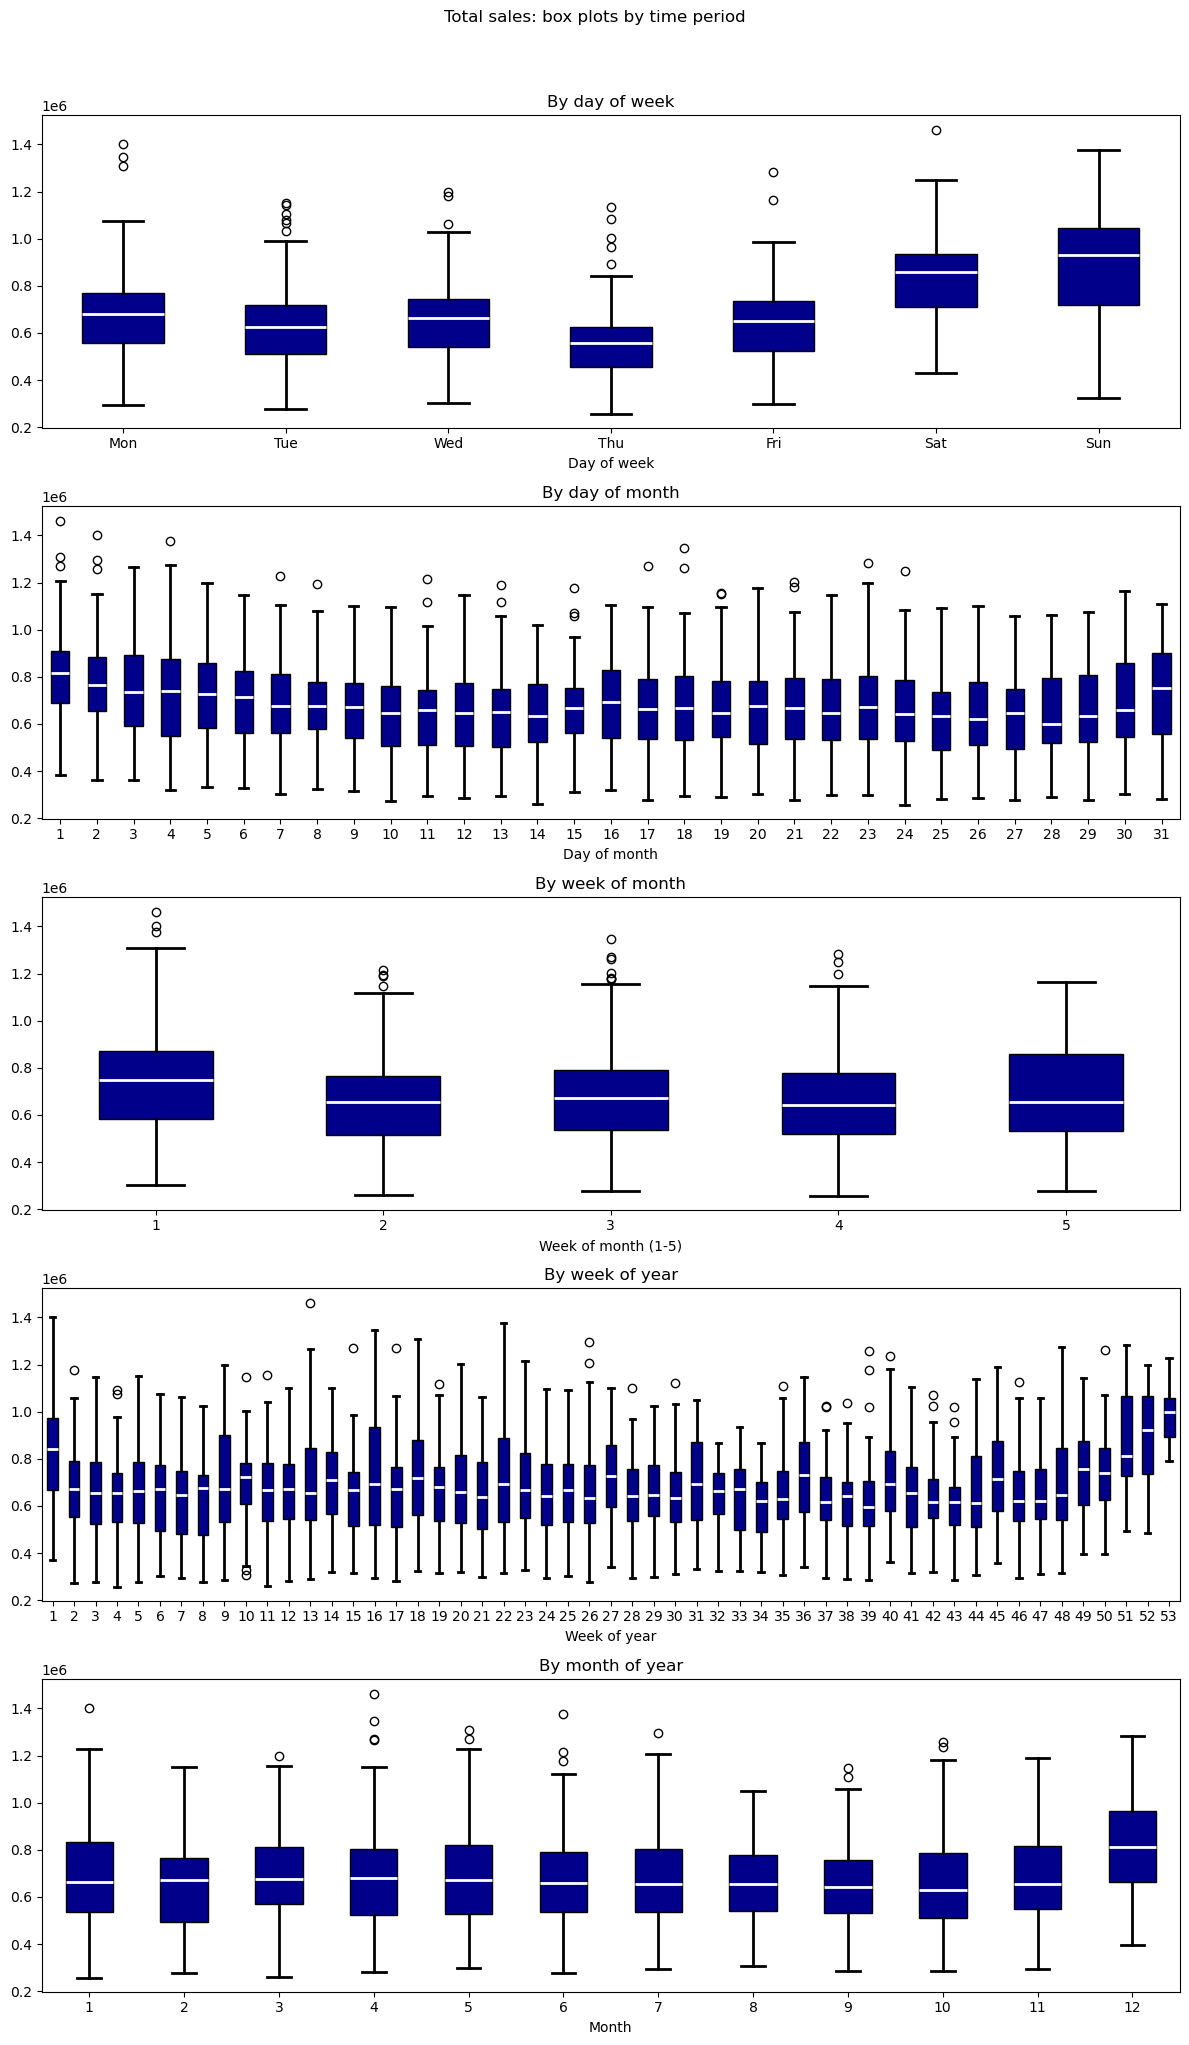

In [268]:
# Box plots of total sales by dow, dom, wom, woy, month (one subplot per row).
# Box plots of total sales (all families) by day of week, day of month, week of month, week of year, month of year
df_plot = pd.DataFrame({"sales": total_repaired.values}, index=total_repaired.index)
df_plot["day_of_week"] = df_plot.index.dayofweek  # 0=Mon, 6=Sun
df_plot["day_of_month"] = df_plot.index.day
df_plot["week_of_month"] = (df_plot.index.day - 1) // 7 + 1  # 1–5
df_plot["week_of_year"] = df_plot.index.isocalendar().week.astype(int)
df_plot["month_of_year"] = df_plot.index.month

fig, axes = plt.subplots(5, 1, figsize=(12, 4 * 5), sharex=False)
axes = axes.flatten()

# Day of week (label with weekday names)
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
def _style_boxplot(bp):
    for patch in bp['boxes']:
        patch.set_facecolor('darkblue')
        patch.set_edgecolor('black')
    for m in bp['medians']:
        m.set_color('white')
        m.set_linewidth(2)
    for w in bp['whiskers']:
        w.set_color('black')
        w.set_linewidth(2)
    for c in bp['caps']:
        c.set_color('black')
        c.set_linewidth(2)

groups_dow = [df_plot[df_plot["day_of_week"] == i]["sales"].values for i in range(7)]
bp0 = axes[0].boxplot(groups_dow, labels=dow_order, patch_artist=True)
_style_boxplot(bp0)
axes[0].set_title("By day of week")
axes[0].set_xlabel("Day of week")

groups_dom = [df_plot[df_plot["day_of_month"] == d]["sales"].values for d in range(1, 32)]
bp1 = axes[1].boxplot(groups_dom, labels=list(range(1, 32)), patch_artist=True)
_style_boxplot(bp1)
axes[1].set_title("By day of month")
axes[1].set_xlabel("Day of month")

groups_wom = [df_plot[df_plot["week_of_month"] == w]["sales"].values for w in range(1, 6)]
bp2 = axes[2].boxplot(groups_wom, labels=list(range(1, 6)), patch_artist=True)
_style_boxplot(bp2)
axes[2].set_title("By week of month")
axes[2].set_xlabel("Week of month (1-5)")

gb_woy = df_plot.groupby("week_of_year")["sales"]
labels_woy = sorted(gb_woy.groups.keys())
groups_woy = [gb_woy.get_group(k).values for k in labels_woy]
bp3 = axes[3].boxplot(groups_woy, labels=labels_woy, patch_artist=True)
_style_boxplot(bp3)
axes[3].set_title("By week of year")
axes[3].set_xlabel("Week of year")

groups_moy = [df_plot[df_plot["month_of_year"] == m]["sales"].values for m in range(1, 13)]
bp4 = axes[4].boxplot(groups_moy, labels=list(range(1, 13)), patch_artist=True)
_style_boxplot(bp4)
axes[4].set_title("By month of year")
axes[4].set_xlabel("Month")

plt.suptitle("Total sales: box plots by time period", y=1.02)
plt.tight_layout()
import os
fig.savefig(os.path.join(os.getcwd(), "box_plots.png"), dpi=180, bbox_inches="tight")
print("Box plot image saved to:", os.path.abspath(os.path.join(os.getcwd(), "box_plots.png")))
plt.show()

## Holt-Winters model (prior to seasonal decomposition)

Fit a **Holt-Winters** (exponential smoothing with trend and seasonality) model on the **repaired total daily sales** series before applying the OLS-based seasonal decomposition below. This gives a baseline forecast from the classical additive Holt-Winters formulation (level, trend, and seasonal period = 7 for weekly).

### ETS(A, A, A) specification

The fitted model is reported as **ETS(A, A, A)** in the summary. This is the standard ETS (Error, Trend, Seasonal) notation:

- **First A (Error):** **A**dditive errors — the observed value is level + trend + seasonal + error (additive structure).
- **Second A (Trend):** **A**dditive trend — the trend component is updated additively (e.g. level + trend from the previous period).
- **Third A (Seasonal):** **A**dditive seasonality — the seasonal effect is added to the level (e.g. level + seasonal index for the current period).

So **ETS(A, A, A)** is the fully **additive** Holt-Winters model: no multiplicative terms. Alternatives would be ETS(M, M, M) (all multiplicative) or mixed forms such as ETS(A, A, M).

### Smoothing and seasonal coefficients (from the fit summary)

- **smoothing_level** (α): Weight on the **level** update. Higher α means the level responds more to recent observations. Typical range (0, 1].
- **smoothing_trend** (β): Weight on the **trend** update. Higher β means the slope is updated more from recent changes in the level.
- **smoothing_seasonal** (γ): Weight on the **seasonal** update. Higher γ means the seasonal indices (e.g. day-of-week effects) are updated more from recent forecast errors.
- **initial_level**, **initial_trend**: Starting values for the level and trend at the beginning of the sample (estimated by the model).
- **initial_seasonal**, **initial_seasonal.L1**, … **initial_seasonal.L5**: Starting values for the seasonal indices. With seasonal period = 7 (weekly), there are 7 − 1 = 6 free seasonal parameters (one category is normalized for identifiability). These are the initial seasonal effects for the first 7 periods used by the state space representation.

Holt-Winters fit on total_repaired (additive trend, seasonal period = 7):
                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                 1679
Model:                   ETS(A, A, A)   Log Likelihood              -21536.667
Date:                Wed, 25 Feb 2026   AIC                          43097.335
Time:                        15:27:22   BIC                          43162.446
Sample:                             0   HQIC                         43121.454
                               - 1679   Scale                   8109345055.726
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.3359      0.011     29.820      0.000       0.314       0.358
smoothing_trend         0.0020

,Model,MAE,RMSE,MAPE (%)
0,Holt-Winters (prior to decomposition),57846.0,90052.0,8.12


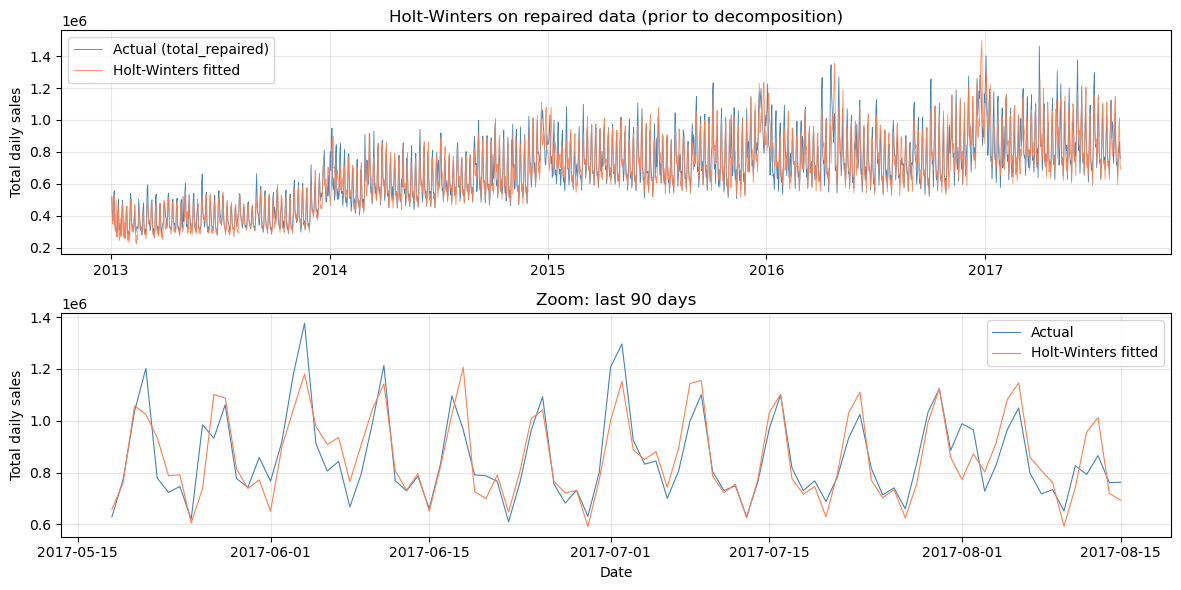

In [269]:
# Holt-Winters (Exponential Smoothing with trend + seasonal) on total_repaired, prior to decomposition.
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing

y_hw = total_repaired.values
hw = ExponentialSmoothing(y_hw, trend=True, seasonal=7)
hw_fit = hw.fit()
print("Holt-Winters fit on total_repaired (additive trend, seasonal period = 7):")
print(hw_fit.summary())

# In-sample fitted values and 30-day ahead forecast
fitted_hw = np.asarray(hw_fit.fittedvalues).flatten()
fc_hw = hw_fit.forecast(30)
print("\n30-day ahead forecast:", np.round(fc_hw, 0))

# MAE, RMSE, MAPE (in-sample: actual vs Holt-Winters fitted)
actual_hw = total_repaired.values
n_align = min(len(actual_hw), len(fitted_hw))
actual_align = actual_hw[-n_align:]
fitted_align = fitted_hw[-n_align:]
def mape_hw(actual, pred):
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask]))
mae_hw = np.mean(np.abs(actual_align - fitted_align))
rmse_hw = np.sqrt(np.mean((actual_align - fitted_align) ** 2))
mape_hw_val = mape_hw(actual_align, fitted_align)
results_hw = pd.DataFrame([{
    "Model": "Holt-Winters (prior to decomposition)",
    "MAE": round(mae_hw, 0),
    "RMSE": round(rmse_hw, 0),
    "MAPE (%)": round(mape_hw_val, 2),
}])
print("\nHolt-Winters in-sample fit: MAE, RMSE, MAPE")
display(results_hw)

# Plot: actual vs Holt-Winters fitted (optional zoom on last 90 days)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
axes[0].plot(total_repaired.index, total_repaired.values, color="steelblue", linewidth=0.6, label="Actual (total_repaired)")
axes[0].plot(total_repaired.index, fitted_hw, color="coral", linewidth=0.6, alpha=0.9, label="Holt-Winters fitted")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("Holt-Winters on repaired data (prior to decomposition)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

tail = 90
axes[1].plot(total_repaired.index[-tail:], total_repaired.values[-tail:], color="steelblue", linewidth=0.8, label="Actual")
axes[1].plot(total_repaired.index[-tail:], fitted_hw[-tail:], color="coral", linewidth=0.8, label="Holt-Winters fitted")
axes[1].set_ylabel("Total daily sales")
axes[1].set_xlabel("Date")
axes[1].set_title("Zoom: last 90 days")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Decomposition method

The series is decomposed into **trend**, **seasonality**, and **residuals** using an additive regression model:

- **Trend** is captured by a linear time trend (constant plus a term linear in the day index).
- **Seasonality** is captured by four additive components:
  - **Day of week:** dummy variables for Monday–Sunday (one category dropped for identifiability).
  - **Day of month:** dummy variables for days 1–31 (one category dropped).
  - **Week of year:** dummy variables for ISO weeks 1–52 (one category dropped).
  - **New Year's Day:** a dummy variable equal to 1 on January 1 and 0 otherwise.

The model is fit by **OLS**: the dependent variable is total daily sales; the regressors are the trend and all seasonal dummies. Fitted values are split into a trend component (constant + trend term) and a seasonal component (sum of the seasonal dummy effects). **Residuals** are observed sales minus the full fitted values.

After fitting, the **ACF** and **PACF** of the residuals are plotted to check for remaining autocorrelation.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     102.3
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:27:23   Log-Likelihood:                -21424.
No. Observations:                1679   AIC:                         4.303e+04
Df Residuals:                    1589   BIC:                         4.352e+04
Df Model:                          89                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.481e+05   2.13e+04     30.382      0.000    6.06e+05     6.9e+05
x1           316.0748      4.388     72.031      0.000     307.468     324.682
x2          1.938e-10   6.36e-11      3.045      0.002     6.9e-11    3.19e-10
x3         -4.671e+04   7885.218     -5.924      0.000   -6.22e+04   -3.12e+04
x4         -1.725e+04   7903.529     -2.182      0.029   -3.27e+04   -1744.871
x5         -1.145e+05   7903.434    -14.493      0.000    -1.3e+05    -9.9e+04
x6         -3.457e+04   7904.730     -4.373      0.000   -5.01e+04   -1.91e+04
x7          1.627e+05   7886.776     20.633      0.000    1.47e+05    1.78e+05
x8          2.282e+05   7904.302     28.866      0.000    2.13e+05    2.44e+05
x9         -4.352e+04   1.69e+04     -2.579      0.010   -7.66e+04   -1.04e+04
x10        -6.312e+04    1.7e+04     -3.707      0.000   -9.65e+04   -2.97e+04
x11        -7.768e+04   1.73e+04     -4.500      0.000   -1.12e+05   -4.38e+04
x12        -1.028e+05   1.75e+04     -5.888      0.000   -1.37e+05   -6.85e+04
x13        -1.213e+05   1.77e+04     -6.849      0.000   -1.56e+05   -8.66e+04
x14        -1.337e+05    1.8e+04     -7.414      0.000   -1.69e+05   -9.83e+04
x15        -1.555e+05   1.84e+04     -8.470      0.000   -1.92e+05   -1.19e+05
x16        -1.586e+05   1.85e+04     -8.555      0.000   -1.95e+05   -1.22e+05
x17        -1.733e+05   1.88e+04     -9.245      0.000    -2.1e+05   -1.37e+05
x18        -1.712e+05    1.9e+04     -9.018      0.000   -2.08e+05   -1.34e+05
x19        -1.804e+05   1.91e+04     -9.430      0.000   -2.18e+05   -1.43e+05
x20        -1.879e+05   1.92e+04     -9.782      0.000   -2.26e+05    -1.5e+05
x21        -1.924e+05   1.93e+04     -9.971      0.000    -2.3e+05   -1.55e+05
x22        -1.727e+05   1.94e+04     -8.914      0.000   -2.11e+05   -1.35e+05
x23        -1.473e+05   1.94e+04     -7.594      0.000   -1.85e+05   -1.09e+05
x24        -1.552e+05   1.94e+04     -8.007      0.000   -1.93e+05   -1.17e+05
x25        -1.517e+05   1.94e+04     -7.816      0.000    -1.9e+05   -1.14e+05
x26         -1.68e+05   1.94e+04     -8.669      0.000   -2.06e+05    -1.3e+05
x27         -1.55e+05   1.92e+04     -8.056      0.000   -1.93e+05   -1.17e+05
x28        -1.563e+05   1.91e+04     -8.193      0.000   -1.94e+05   -1.19e+05
x29        -1.618e+05   1.89e+04     -8.539      0.000   -1.99e+05   -1.25e+05
x30        -1.538e+05   1.87e+04     -8.238      0.000    -1.9e+05   -1.17e+05
x31        -1.743e+05   1.84e+04     -9.463      0.000    -2.1e+05   -1.38e+05
x32        -1.885e+05   1.85e+04    -10.185      0.000   -2.25e+05   -1.52e+05
x33        -1.999e+05    1.8e+04    -11.107      0.000   -2.35e+05   -1.65e+05
x34        -2.125e+05   1.77e+04    -12.035      0.000   -2.47e+05   -1.78e+05
x35        -2.002e+05   1.74e+04    -11.516      0.000   -2.34e+05   -1.66e+05
x3

Variable meanings (OLS summary uses x0, x1, ...):


,Variable,Meaning
0,x0,Constant
1,x1,Linear trend (day index)
2,x2,"New Year's Day (1=Jan 1, 0=otherwise)"
3,x3,Tuesday (vs Monday)
4,x4,Wednesday (vs Monday)
...,...,...
86,x86,Week of year 49 (vs week 1)
87,x87,Week of year 50 (vs week 1)
88,x88,Week of year 51 (vs week 1)
89,x89,Week of year 52 (vs week 1)


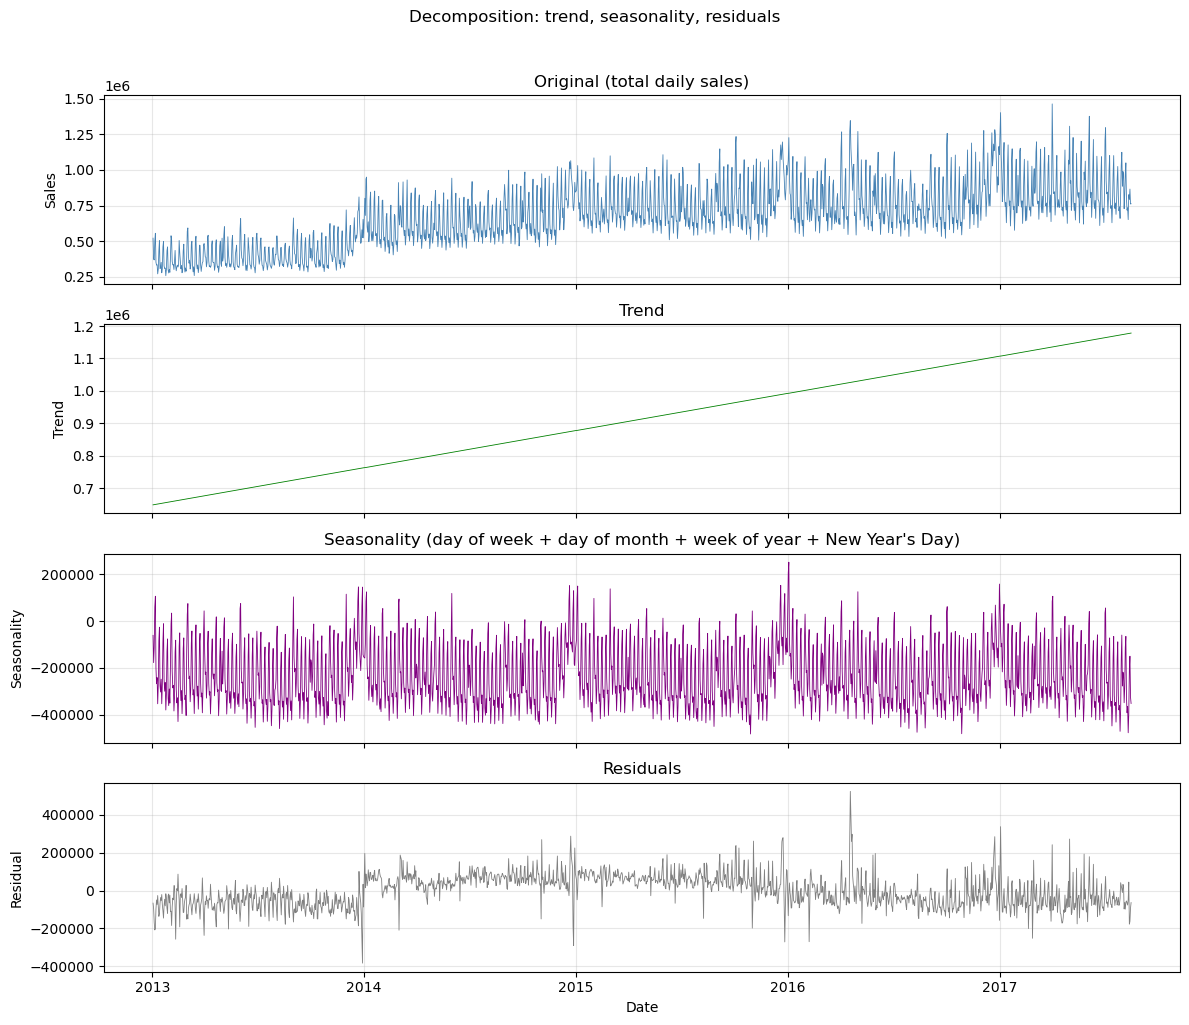

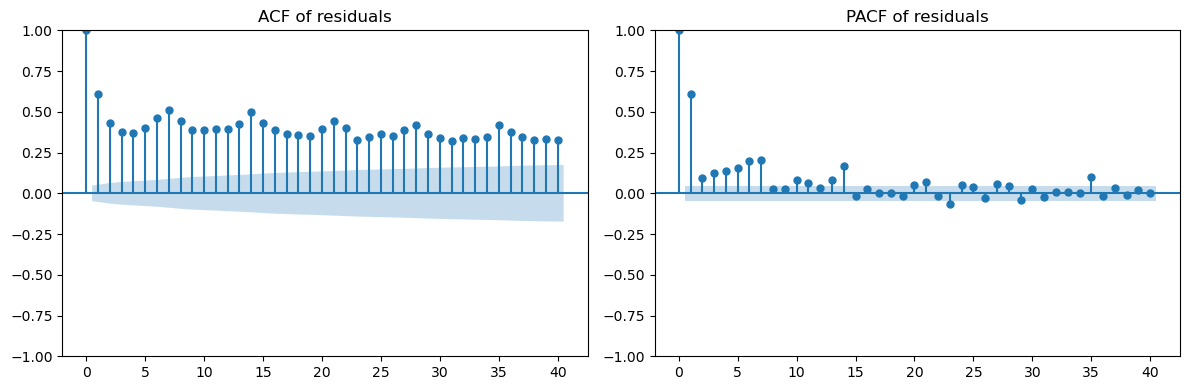

In [270]:
# OLS decomposition: trend + dow, dom, woy, New Year's Day; ACF/PACF of residuals; summary and variable table.
# Decompose sales into trend, seasonality (day of week, day of month, week of year, New Year's Day), and residuals. Plot ACF/PACF of residuals.
from statsmodels.api import OLS, add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = total_repaired.values
n = len(y)
df = pd.DataFrame({"y": y, "trend": np.arange(n)}, index=total_repaired.index)
df["dow"] = df.index.dayofweek
df["dom"] = df.index.day
df["woy"] = df.index.isocalendar().week.astype(int)
df["newyear"] = ((df.index.month == 1) & (df.index.day == 1)).astype(np.float64)

X = add_constant(df[["trend"]])
X["newyear"] = df["newyear"]
X = X.join(pd.get_dummies(df["dow"], prefix="dow", drop_first=True))
X = X.join(pd.get_dummies(df["dom"], prefix="dom", drop_first=True))
X = X.join(pd.get_dummies(df["woy"], prefix="woy", drop_first=True))
# Convert to float arrays to avoid statsmodels "dtype of object" error
X_arr = np.asarray(X, dtype=np.float64)
y_arr = np.asarray(y, dtype=np.float64)
model = OLS(y_arr, X_arr).fit()
display(model.summary())

# Variable meaning table (summary uses x0, x1, ... when exog is numpy)
dow_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
meanings = {"const": "Constant", "trend": "Linear trend (day index)", "newyear": "New Year's Day (1=Jan 1, 0=otherwise)"}
for i in range(1, 7):
    meanings["dow_" + str(i)] = dow_names[i] + " (vs Monday)"
for d in range(2, 32):
    meanings["dom_" + str(d)] = "Day of month " + str(d) + " (vs 1st)"
for w in range(2, 53):
    meanings["woy_" + str(w)] = "Week of year " + str(w) + " (vs week 1)"
var_meaning = pd.DataFrame({"Variable": ["x" + str(i) for i in range(len(X.columns))], "Meaning": [meanings.get(c, c) for c in X.columns]})
print("Variable meanings (OLS summary uses x0, x1, ...):")
display(var_meaning)

fitted = model.predict(X_arr)
trend_fitted = model.params[0] + model.params[1] * df["trend"].values
seasonal_fitted = fitted - trend_fitted
resid = (df["y"] - fitted).values
resid_index = df.index  # index aligned with resid (for promotion analysis and others)

# Plots: original, trend, seasonality, residuals
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(total_repaired.index, y, color="steelblue", linewidth=0.6)
axes[0].set_ylabel("Sales")
axes[0].set_title("Original (total daily sales)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(total_repaired.index, trend_fitted, color="green", linewidth=0.6)
axes[1].set_ylabel("Trend")
axes[1].set_title("Trend")
axes[1].grid(True, alpha=0.3)

axes[2].plot(total_repaired.index, seasonal_fitted, color="purple", linewidth=0.6)
axes[2].set_ylabel("Seasonality")
axes[2].set_title("Seasonality (day of week + day of month + week of year + New Year's Day)")
axes[2].grid(True, alpha=0.3)

axes[3].plot(total_repaired.index, resid, color="gray", linewidth=0.6)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")
axes[3].set_title("Residuals")
axes[3].grid(True, alpha=0.3)

plt.suptitle("Decomposition: trend, seasonality, residuals", y=1.02)
plt.tight_layout()
plt.show()

# ACF and PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=40, ax=axes[0], title="ACF of residuals")
plot_pacf(resid, lags=40, ax=axes[1], title="PACF of residuals")
plt.tight_layout()
plt.show()

In [271]:
# VIF for seasonal coefficients; report only coefficients with VIF > 5.
# Variance Inflation Factor (VIF) for seasonal coefficients; report only VIF > 5
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seasonal columns: indices 2 onwards (skip const=0, trend=1)
vif_list = []
for i in range(2, X_arr.shape[1]):
    try:
        v = variance_inflation_factor(X_arr, i)
    except Exception:
        v = np.nan
    vif_list.append({"Variable": X.columns[i], "VIF": v})
vif_df = pd.DataFrame(vif_list)
vif_high = vif_df[vif_df["VIF"] > 5].sort_values("VIF", ascending=False)
if len(vif_high) > 0:
    print("Seasonal coefficients with VIF > 5:")
    display(vif_high)
else:
    print("No seasonal coefficients with VIF > 5.")

c:\Users\cbailey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


No seasonal coefficients with VIF > 5.


**Residual PACF interpretation:** The PACF of the residuals shows significant autocorrelation at lags 1–7 and at lag 14, indicating that the regression-based decomposition has not fully captured the dependence in the series; remaining correlation at these lags may warrant an autoregressive (AR) component or additional seasonal structure (e.g. biweekly) in a fuller model.

### Model performance metrics: formulas

The following metrics are used to evaluate forecast accuracy. For each, *n* is the number of forecast points, *y*<sub>*i*</sub> is the actual value, and *ŷ*<sub>*i*</sub> is the predicted value.

- **MAE (Mean Absolute Error):**  
  MAE = (1/*n*) Σ |*y*<sub>*i*</sub> − *ŷ*<sub>*i*</sub>|

- **RMSE (Root Mean Squared Error):**  
  RMSE = √[ (1/*n*) Σ (*y*<sub>*i*</sub> − *ŷ*<sub>*i*</sub>)² ]

- **MAPE (Mean Absolute Percentage Error), in percent:**  
  MAPE = 100 × (1/*n*) Σ |*y*<sub>*i*</sub> − *ŷ*<sub>*i*</sub>| / |*y*<sub>*i*</sub>|  
  (Summation is over observations where *y*<sub>*i*</sub> ≠ 0 to avoid division by zero.)

**Seasonally adjusted forecast pipeline:** (1) Form the seasonally adjusted series (original minus fitted seasonal from OLS). (2) Split 80% train / 20% test (from 2014 onward) and fit **ETS** and **ARIMA** on the adjusted train series. (3) Forecast 30 days ahead on the adjusted scale. (4) Add back the OLS seasonal component for those 30 dates (same regressor structure as in the decomposition) to obtain forecasts in original (total sales) units. Plots show train (SA), test (SA), each forecast with seasonal added back, and actual total sales.

c:\Users\cbailey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Model specifications (seasonally adjusted forecast: ETS and ARIMA):


,Model,Specification,Description
0,ETS,"Exponential smoothing (state space), additive ...",Fit on seasonally adjusted (SA) train series; ...
1,ARIMA,"ARIMA(p=2, d=1, q=2).",Fit on SA train series; forecast 30 steps on S...


Forecasts on SA series with seasonal added back (30 days):


,Method,MAE,RMSE,MAPE (%)
0,ETS,55903.0,84049.0,5.63
1,ARIMA,68235.0,95826.0,6.78


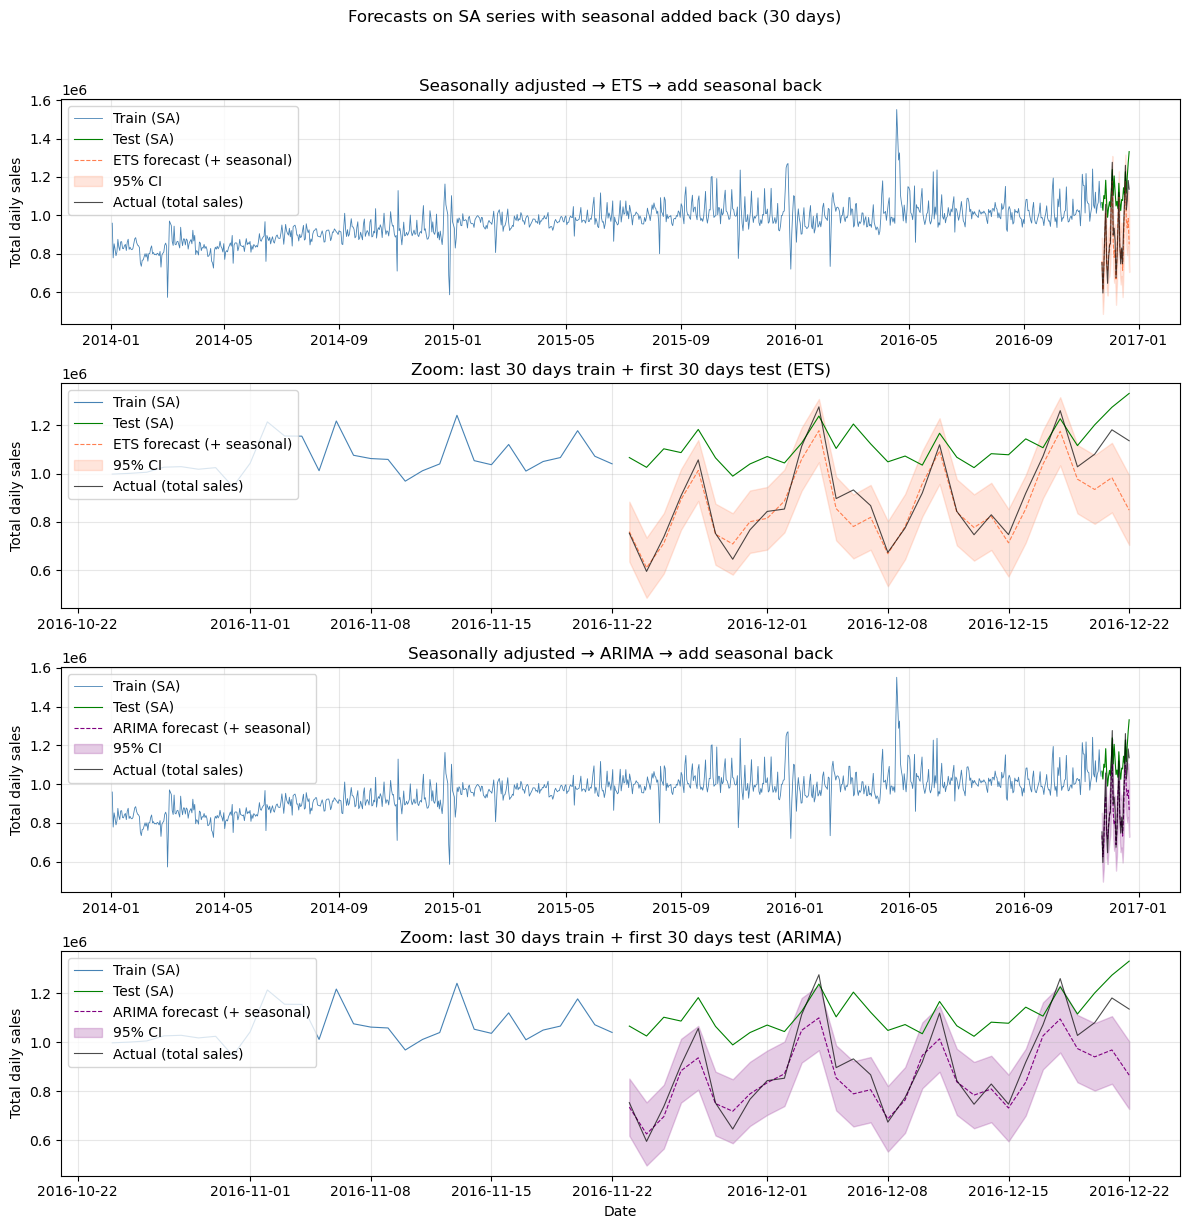

In [272]:
# Seasonally adjusted → ETS/ARIMA fit → 30-day forecast → add seasonal back; plots and MAE/RMSE/MAPE; 95% CIs.
# Seasonally adjusted series → ETS/ARIMA → forecast → add seasonal back
# Requires decomposition cell run first (model, X, seasonal_fitted, total_repaired).
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Seasonally adjusted series (exclude 2013)
sa_series = total_repaired - pd.Series(seasonal_fitted, index=total_repaired.index)
sa_series = sa_series[sa_series.index >= "2014-01-01"].sort_index()
n_sa = len(sa_series)
train_size = int(0.8 * n_sa)
train_sa = sa_series.iloc[:train_size]
test_sa = sa_series.iloc[train_size:]
horizon = 30
future_dates = test_sa.index[:horizon]

# Build seasonal component for future dates (same regressor structure as decomposition)
seasonal_cols = [c for c in X.columns if c not in ("const", "trend")]
beta_seasonal = np.asarray(model.params[2:])
X_fut = pd.DataFrame(0.0, index=range(horizon), columns=X.columns)
for i, date in enumerate(future_dates):
    X_fut.loc[i, "const"] = 1
    X_fut.loc[i, "trend"] = train_size + i
    X_fut.loc[i, "newyear"] = 1.0 if (date.month == 1 and date.day == 1) else 0.0
    if date.dayofweek >= 1:
        c = "dow_" + str(date.dayofweek)
        if c in X_fut.columns:
            X_fut.loc[i, c] = 1.0
    if date.day >= 2:
        c = "dom_" + str(date.day)
        if c in X_fut.columns:
            X_fut.loc[i, c] = 1.0
    w = date.isocalendar().week
    if w >= 2 and w <= 52:
        c = "woy_" + str(w)
        if c in X_fut.columns:
            X_fut.loc[i, c] = 1.0
seasonal_future = X_fut[seasonal_cols].values @ beta_seasonal

# ETS on adjusted series (with forecast confidence interval; state space for get_forecast)
ets_sa = ExponentialSmoothing(train_sa.values, trend=True, seasonal=7)
ets_fit_sa = ets_sa.fit()
ets_forecast_obj = ets_fit_sa.get_forecast(horizon)
ets_fc_sa = ets_forecast_obj.predicted_mean
ets_conf_sa = ets_forecast_obj.conf_int(alpha=0.05)
ets_fc = ets_fc_sa + seasonal_future
ets_fc_lower = np.asarray(ets_conf_sa[:, 0]) + seasonal_future
ets_fc_upper = np.asarray(ets_conf_sa[:, 1]) + seasonal_future

# ARIMA on adjusted series (with forecast confidence interval)
arima_sa = ARIMA(train_sa.values, order=(2, 1, 2))
arima_fit_sa = arima_sa.fit()
arima_forecast_obj = arima_fit_sa.get_forecast(horizon)
arima_fc_sa = arima_forecast_obj.predicted_mean
arima_conf_sa = arima_forecast_obj.conf_int(alpha=0.05)
arima_fc = arima_fc_sa + seasonal_future
arima_fc_lower = np.asarray(arima_conf_sa[:, 0]) + seasonal_future
arima_fc_upper = np.asarray(arima_conf_sa[:, 1]) + seasonal_future

# Plot: train adjusted, test actual (SA), forecasts (with seasonal added back), and actual total sales; then zoomed (last 30 train + first 30 test)
actual_test = total_repaired.reindex(future_dates).dropna()
train_tail_30 = train_sa.iloc[-horizon:]
test_head_30 = test_sa.iloc[:horizon]

# MAE, RMSE, MAPE (round MAE/RMSE to whole number, MAPE as percent)
def mape(actual, pred):
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

# Model specifications (SA pipeline: ETS and ARIMA on seasonally adjusted series)
specs_sa = pd.DataFrame([
    {"Model": "ETS", "Specification": "Exponential smoothing (state space), additive trend, seasonal period = 7 (weekly).", "Description": "Fit on seasonally adjusted (SA) train series; forecast 30 days on SA scale; add back OLS seasonal component to get total sales forecast."},
    {"Model": "ARIMA", "Specification": "ARIMA(p=2, d=1, q=2).", "Description": "Fit on SA train series; forecast 30 steps on SA scale; add back OLS seasonal component to get total sales forecast."},
])
print("Model specifications (seasonally adjusted forecast: ETS and ARIMA):")
display(specs_sa)

actual_30 = actual_test.values
results_sa = []
for name, pred in [("ETS", ets_fc), ("ARIMA", arima_fc)]:
    results_sa.append({
        "Method": name,
        "MAE": round(np.mean(np.abs(actual_30 - pred)), 0),
        "RMSE": round(np.sqrt(np.mean((actual_30 - pred) ** 2)), 0),
        "MAPE (%)": round(mape(actual_30, pred), 2),
    })
print("Forecasts on SA series with seasonal added back (30 days):")
display(pd.DataFrame(results_sa))

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=False)
# Full ETS
axes[0].plot(train_sa.index, train_sa.values, color="steelblue", linewidth=0.6, label="Train (SA)")
axes[0].plot(future_dates, test_sa.iloc[:horizon].values, color="green", linewidth=0.8, label="Test (SA)")
axes[0].plot(future_dates, ets_fc, color="coral", linewidth=0.8, linestyle="--", label="ETS forecast (+ seasonal)")
axes[0].fill_between(future_dates, ets_fc_lower, ets_fc_upper, color="coral", alpha=0.2, label="95% CI")
axes[0].plot(future_dates, actual_test.values, color="black", linewidth=0.8, alpha=0.7, label="Actual (total sales)")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("Seasonally adjusted → ETS → add seasonal back")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)
# Zoom ETS: last 30 days train + first 30 days test
axes[1].plot(train_tail_30.index, train_tail_30.values, color="steelblue", linewidth=0.8, label="Train (SA)")
axes[1].plot(future_dates, test_head_30.values, color="green", linewidth=0.8, label="Test (SA)")
axes[1].plot(future_dates, ets_fc, color="coral", linewidth=0.8, linestyle="--", label="ETS forecast (+ seasonal)")
axes[1].fill_between(future_dates, ets_fc_lower, ets_fc_upper, color="coral", alpha=0.2, label="95% CI")
axes[1].plot(future_dates, actual_test.values, color="black", linewidth=0.8, alpha=0.7, label="Actual (total sales)")
axes[1].set_ylabel("Total daily sales")
axes[1].set_title("Zoom: last 30 days train + first 30 days test (ETS)")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

# Full ARIMA
axes[2].plot(train_sa.index, train_sa.values, color="steelblue", linewidth=0.6, label="Train (SA)")
axes[2].plot(future_dates, test_sa.iloc[:horizon].values, color="green", linewidth=0.8, label="Test (SA)")
axes[2].plot(future_dates, arima_fc, color="purple", linewidth=0.8, linestyle="--", label="ARIMA forecast (+ seasonal)")
axes[2].fill_between(future_dates, arima_fc_lower, arima_fc_upper, color="purple", alpha=0.2, label="95% CI")
axes[2].plot(future_dates, actual_test.values, color="black", linewidth=0.8, alpha=0.7, label="Actual (total sales)")
axes[2].set_ylabel("Total daily sales")
axes[2].set_title("Seasonally adjusted → ARIMA → add seasonal back")
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)
# Zoom ARIMA: last 30 days train + first 30 days test
axes[3].plot(train_tail_30.index, train_tail_30.values, color="steelblue", linewidth=0.8, label="Train (SA)")
axes[3].plot(future_dates, test_head_30.values, color="green", linewidth=0.8, label="Test (SA)")
axes[3].plot(future_dates, arima_fc, color="purple", linewidth=0.8, linestyle="--", label="ARIMA forecast (+ seasonal)")
axes[3].fill_between(future_dates, arima_fc_lower, arima_fc_upper, color="purple", alpha=0.2, label="95% CI")
axes[3].plot(future_dates, actual_test.values, color="black", linewidth=0.8, alpha=0.7, label="Actual (total sales)")
axes[3].set_ylabel("Total daily sales")
axes[3].set_xlabel("Date")
axes[3].set_title("Zoom: last 30 days train + first 30 days test (ARIMA)")
axes[3].legend(loc="upper left")
axes[3].grid(True, alpha=0.3)
plt.suptitle("Forecasts on SA series with seasonal added back (30 days)", y=1.02)
plt.tight_layout()
plt.show()

15:27:28 - cmdstanpy - INFO - Chain [1] start processing
15:27:28 - cmdstanpy - INFO - Chain [1] done processing


Model specification (Prophet 30-day ahead forecast):


,Model,Specification,Description
0,Prophet,"Prophet with yearly_seasonality=True, weekly_s...",Fit on total daily sales (80% train from 2014 ...


Prophet 30-day ahead forecast (80% train):


,Method,MAE,RMSE,MAPE (%)
0,Prophet,88997.0,118626.0,9.22


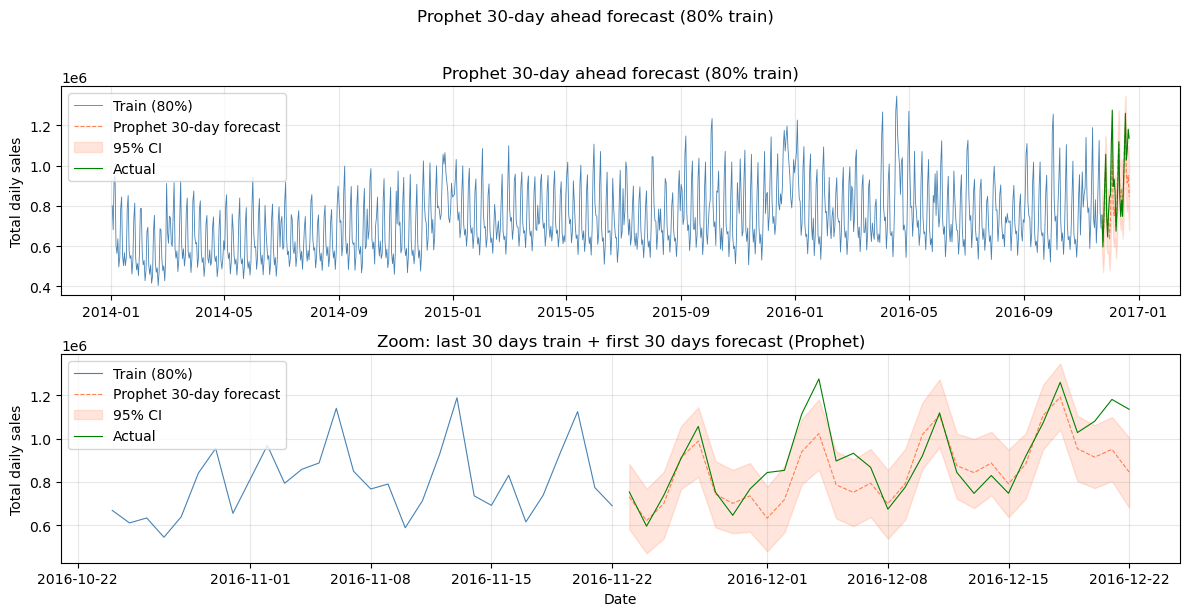

In [273]:
# Prophet 30-day forecast on total sales; same split; plots (full + zoom), metrics, 95% CIs.
# Prophet 30-day ahead forecast using 80% train data (same split as SA pipeline)
from prophet import Prophet

data_2014 = total_repaired[total_repaired.index >= "2014-01-01"].sort_index()
n = len(data_2014)
train_size = int(0.8 * n)
train_prophet = data_2014.iloc[:train_size]
train_df = pd.DataFrame({"ds": train_prophet.index, "y": train_prophet.values})

prophet_m = Prophet(yearly_seasonality=True, weekly_seasonality=True, interval_width=0.95)
prophet_m.fit(train_df)
future_30 = prophet_m.make_future_dataframe(periods=30)
forecast_30 = prophet_m.predict(future_30)
prophet_fc = forecast_30["yhat"].tail(30).values
prophet_fc_lower = forecast_30["yhat_lower"].tail(30).values
prophet_fc_upper = forecast_30["yhat_upper"].tail(30).values
fc_dates = forecast_30["ds"].tail(30)

# Plot: train, 30-day forecast (with CI), and (if available) actual; then zoomed (last 30 train + first 30 forecast)
actual_fc = total_repaired.reindex(pd.to_datetime(fc_dates))
train_tail_30 = train_prophet.iloc[-30:]

# MAE, RMSE, MAPE (round MAE/RMSE to whole number, MAPE as percent)
valid = actual_fc.notna()
if valid.sum() > 0:
    # Model specification (Prophet 30-day on total sales)
    specs_prophet = pd.DataFrame([{
        "Model": "Prophet",
        "Specification": "Prophet with yearly_seasonality=True, weekly_seasonality=True, interval_width=0.95.",
        "Description": "Fit on total daily sales (80% train from 2014 onward); 30-day ahead forecast on original scale.",
    }])
    print("Model specification (Prophet 30-day ahead forecast):")
    display(specs_prophet)

    actual_p = actual_fc.values[valid.values]
    pred_p = prophet_fc[valid.values]

    def mape(actual, pred):
        mask = actual != 0
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

    results_prophet = pd.DataFrame([{
        "Method": "Prophet",
        "MAE": round(float(np.mean(np.abs(actual_p - pred_p))), 0),
        "RMSE": round(float(np.sqrt(np.mean((actual_p - pred_p) ** 2))), 0),
        "MAPE (%)": round(mape(actual_p, pred_p), 2),
    }])
    print("Prophet 30-day ahead forecast (80% train):")
    display(results_prophet)
else:
    print("No actuals available for forecast period; skipping MAE/RMSE/MAPE.")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
axes[0].plot(train_prophet.index, train_prophet.values, color="steelblue", linewidth=0.6, label="Train (80%)")
axes[0].plot(fc_dates, prophet_fc, color="coral", linewidth=0.8, linestyle="--", label="Prophet 30-day forecast")
axes[0].fill_between(fc_dates, prophet_fc_lower, prophet_fc_upper, color="coral", alpha=0.2, label="95% CI")
if actual_fc.notna().any():
    axes[0].plot(actual_fc.dropna().index, actual_fc.dropna().values, color="green", linewidth=0.8, label="Actual")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("Prophet 30-day ahead forecast (80% train)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_tail_30.index, train_tail_30.values, color="steelblue", linewidth=0.8, label="Train (80%)")
axes[1].plot(fc_dates, prophet_fc, color="coral", linewidth=0.8, linestyle="--", label="Prophet 30-day forecast")
axes[1].fill_between(fc_dates, prophet_fc_lower, prophet_fc_upper, color="coral", alpha=0.2, label="95% CI")
if actual_fc.notna().any():
    axes[1].plot(actual_fc.dropna().index, actual_fc.dropna().values, color="green", linewidth=0.8, label="Actual")
axes[1].set_ylabel("Total daily sales")
axes[1].set_xlabel("Date")
axes[1].set_title("Zoom: last 30 days train + first 30 days forecast (Prophet)")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)
plt.suptitle("Prophet 30-day ahead forecast (80% train)", y=1.02)
plt.tight_layout()
plt.show()

15:27:29 - cmdstanpy - INFO - Chain [1] start processing
15:27:29 - cmdstanpy - INFO - Chain [1] done processing


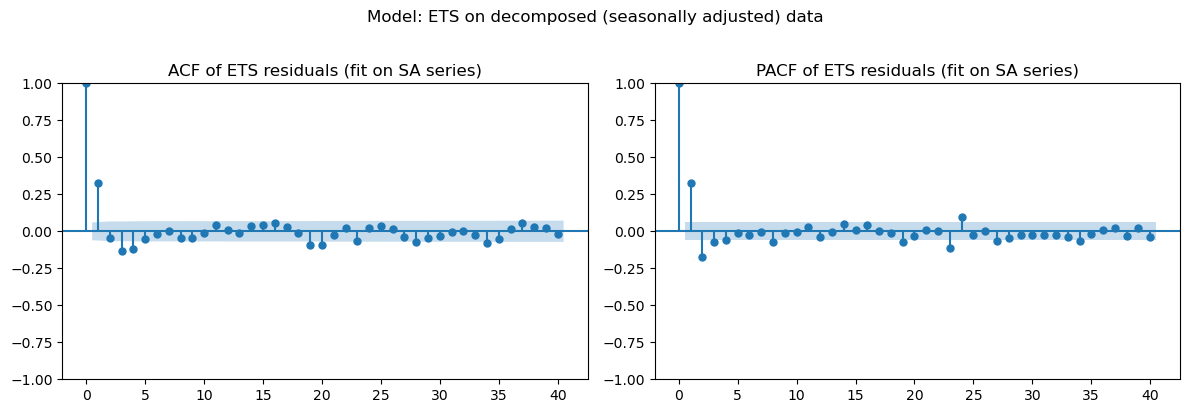

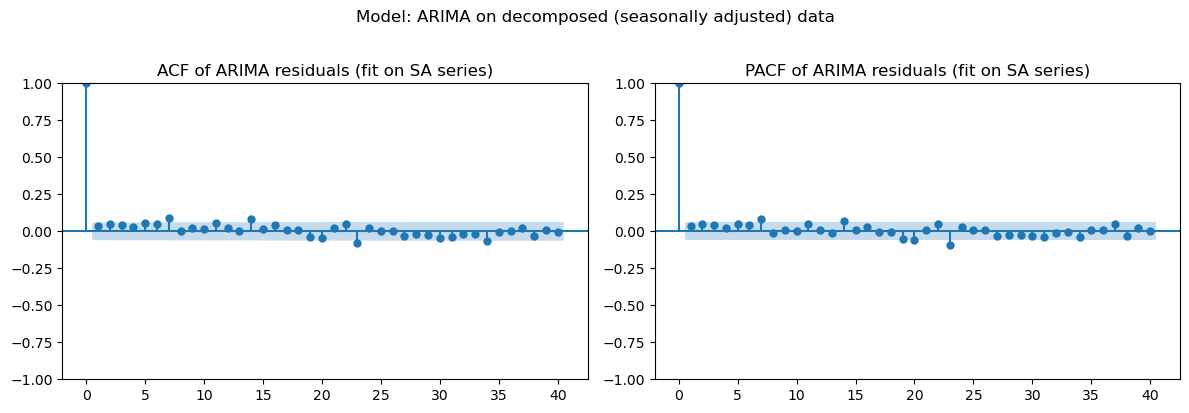

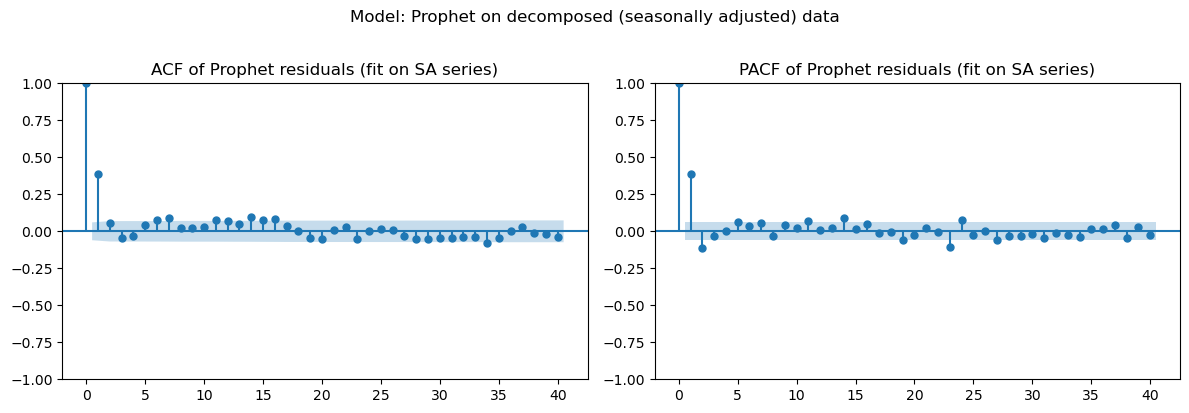

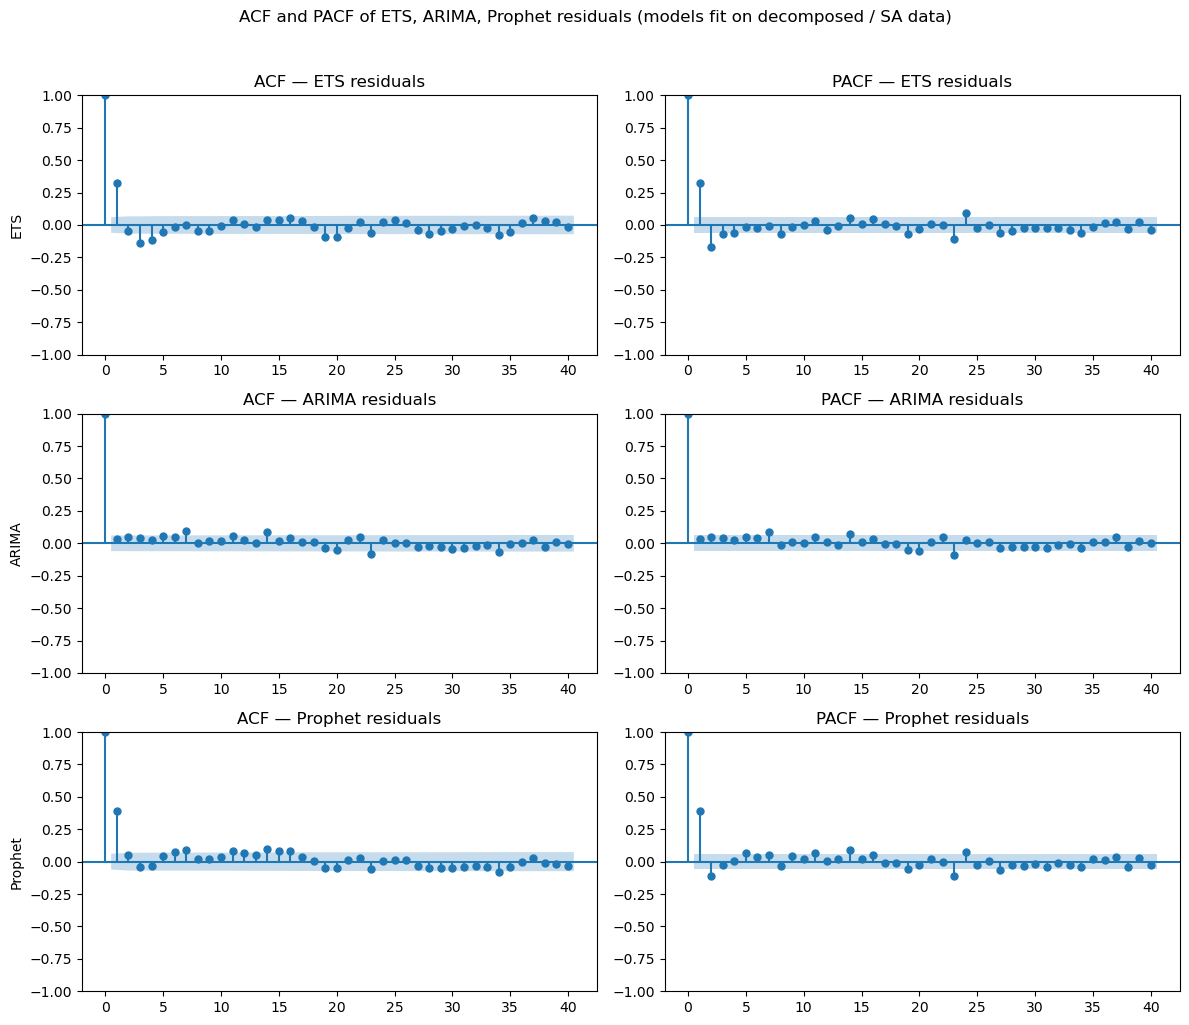

Exported ACF/PACF plots:
  data\ACF_PACF_ETS_residuals.png
  data\ACF_PACF_ARIMA_residuals.png
  data\ACF_PACF_Prophet_residuals.png
  data\ACF_PACF_ETS_ARIMA_Prophet_residuals.png


In [274]:
# ACF and PACF of residuals from ETS, ARIMA, and Prophet fit on decomposed (seasonally adjusted) data.
# Requires: decomposition cell and SA forecast cell run (train_sa, ets_fit_sa, arima_fit_sa).
# Prophet is fit here on train_sa for consistency with ETS/ARIMA (all on decomposed data).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
import os

# --- ETS residuals (from fit on train_sa) ---
if hasattr(ets_fit_sa, "resid"):
    resid_ets = np.asarray(ets_fit_sa.resid).flatten()
else:
    fitted_ets = np.asarray(ets_fit_sa.fittedvalues).flatten()
    n_ets = min(len(train_sa), len(fitted_ets))
    resid_ets = train_sa.values[-n_ets:] - fitted_ets[-n_ets:]

# --- ARIMA residuals ---
resid_arima = np.asarray(arima_fit_sa.resid).flatten()

# --- Prophet on train_sa (decomposed), then in-sample residuals ---
df_sa = pd.DataFrame({"ds": train_sa.index, "y": train_sa.values})
prophet_sa = Prophet(yearly_seasonality=True, weekly_seasonality=True)
prophet_sa.fit(df_sa)
pred_sa = prophet_sa.predict(df_sa[["ds"]])
resid_prophet = (train_sa.values - pred_sa["yhat"].values).flatten()

# --- ACF/PACF plots: one figure per model, 2 subplots each (ACF, PACF) ---
lags = 40
export_dir = DATA
os.makedirs(export_dir, exist_ok=True)
saved_paths = []

for name, resid, color in [
    ("ETS", resid_ets, "coral"),
    ("ARIMA", resid_arima, "purple"),
    ("Prophet", resid_prophet, "green"),
]:
    resid_clean = np.asarray(resid)
    resid_clean = resid_clean[~np.isnan(resid_clean)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(resid_clean, lags=lags, ax=axes[0], title=f"ACF of {name} residuals (fit on SA series)")
    plot_pacf(resid_clean, lags=lags, ax=axes[1], title=f"PACF of {name} residuals (fit on SA series)")
    plt.suptitle(f"Model: {name} on decomposed (seasonally adjusted) data", y=1.02)
    plt.tight_layout()
    fname = os.path.join(export_dir, f"ACF_PACF_{name}_residuals.png")
    fig.savefig(fname, dpi=180, bbox_inches="tight")
    saved_paths.append(fname)
    plt.show()

# Combined figure: 3 rows (ETS, ARIMA, Prophet) x 2 cols (ACF, PACF)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
plot_acf(resid_ets[~np.isnan(resid_ets)], lags=lags, ax=axes[0, 0], title="ACF — ETS residuals")
plot_pacf(resid_ets[~np.isnan(resid_ets)], lags=lags, ax=axes[0, 1], title="PACF — ETS residuals")
plot_acf(resid_arima, lags=lags, ax=axes[1, 0], title="ACF — ARIMA residuals")
plot_pacf(resid_arima, lags=lags, ax=axes[1, 1], title="PACF — ARIMA residuals")
plot_acf(resid_prophet, lags=lags, ax=axes[2, 0], title="ACF — Prophet residuals")
plot_pacf(resid_prophet, lags=lags, ax=axes[2, 1], title="PACF — Prophet residuals")
axes[0, 0].set_ylabel("ETS")
axes[1, 0].set_ylabel("ARIMA")
axes[2, 0].set_ylabel("Prophet")
plt.suptitle("ACF and PACF of ETS, ARIMA, Prophet residuals (models fit on decomposed / SA data)", y=1.02)
plt.tight_layout()
combined_path = os.path.join(export_dir, "ACF_PACF_ETS_ARIMA_Prophet_residuals.png")
fig.savefig(combined_path, dpi=180, bbox_inches="tight")
saved_paths.append(combined_path)
plt.show()

print("Exported ACF/PACF plots:")
for p in saved_paths:
    print(" ", p)

In [275]:
# Regress decomposition residuals on daily sum of onpromotion (OLS).
# OLS regression: residuals from seasonal decomposition (y) on daily sum of onpromotion (x)
# Requires decomposition cell run first (resid, resid_index). Load train for onpromotion.
from statsmodels.api import OLS, add_constant

train = pd.read_csv(f"{DATA}/train.csv", parse_dates=["date"])
daily_onpromo = train.groupby("date")["onpromotion"].sum()
# Use index that matches resid length (in case resid_index was from a different run)
n_resid = len(resid)
if len(resid_index) == n_resid:
    index_for_resid = resid_index
elif len(total_repaired) == n_resid:
    index_for_resid = total_repaired.index
else:
    index_for_resid = total_repaired.index[-n_resid:]
resid_series = pd.Series(resid, index=index_for_resid)
df_ols = pd.DataFrame({"resid": resid_series, "onpromo": daily_onpromo.reindex(resid_series.index).fillna(0)}).dropna(subset=["resid"])
X_opo = add_constant(df_ols[["onpromo"]])
model_opo = OLS(df_ols["resid"], X_opo).fit()
print("OLS: residuals (from seasonal decomposition) ~ daily sum of onpromotion")
display(model_opo.summary())

OLS: residuals (from seasonal decomposition) ~ daily sum of onpromotion


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  resid   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6259
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.429
Time:                        15:27:34   Log-Likelihood:                -13098.
No. Observations:                1052   AIC:                         2.620e+04
Df Residuals:                    1050   BIC:                         2.621e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2060.9437   3210.324      0.642      0.521   -4238.438    8360.325
onpromo       -0.2824      0.357     -0.791      0.429      -0.983       0.418
==============================================================================
Omnibus:                      310.600   Durbin-Watson:                   1.219
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5416.998
Skew:                           0.884   Prob(JB):                         0.00
Kurtosis:                      13.975   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

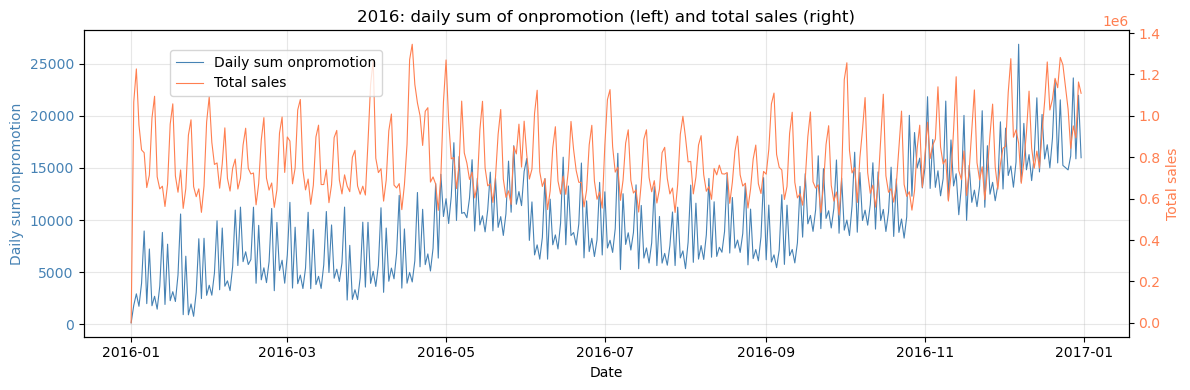

In [276]:
# 2016: daily onpromotion (primary y-axis) vs total sales (secondary y-axis).
# 2016: daily sum of onpromotion (primary y-axis) and total sales (secondary y-axis)
train = pd.read_csv(f"{DATA}/train.csv", parse_dates=["date"])
daily_onpromo = train.groupby("date")["onpromotion"].sum()
onpromo_2016 = daily_onpromo[daily_onpromo.index.year == 2016]
sales_2016 = total_repaired[total_repaired.index.year == 2016].reindex(onpromo_2016.index).fillna(0)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(onpromo_2016.index, onpromo_2016.values, color="steelblue", linewidth=0.8, label="Daily sum onpromotion")
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily sum onpromotion", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(sales_2016.index, sales_2016.values, color="coral", linewidth=0.8, label="Total sales")
ax2.set_ylabel("Total sales", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

plt.title("2016: daily sum of onpromotion (left) and total sales (right)")
fig.legend(loc="upper left", bbox_to_anchor=(0.14, 0.88))
plt.tight_layout()
plt.show()

In [277]:
# Correlation between daily sum of onpromotion and daily total sales.
# Correlation between daily sum of onpromotion and daily (total) sales
train = pd.read_csv(f"{DATA}/train.csv", parse_dates=["date"])
daily_onpromo = train.groupby("date")["onpromotion"].sum()
aligned = pd.DataFrame({"onpromotion": daily_onpromo.reindex(total_repaired.index).fillna(0), "sales": total_repaired}).dropna()
corr = aligned["onpromotion"].corr(aligned["sales"])
print(f"Correlation coefficient (daily sum onpromotion vs daily total sales): {corr:.4f}")

Correlation coefficient (daily sum onpromotion vs daily total sales): 0.4930


## Prophet on repaired data (prior to decomposition)

Fit a Prophet model directly on the **total repaired daily sales** series, without using the OLS decomposition or seasonally adjusted series. Use the first 80% of the repaired series for training, then produce a **30-day ahead forecast** into the test period (last 20% of the series) and evaluate MAE, RMSE, and MAPE on those 30 days.

15:27:37 - cmdstanpy - INFO - Chain [1] start processing
15:27:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet on repaired data (80% train, 30-day ahead on test):


,Method,MAE,RMSE,MAPE (%)
0,"Prophet (repaired, 80% train, 30-day ahead)",76462.0,102267.0,10.08


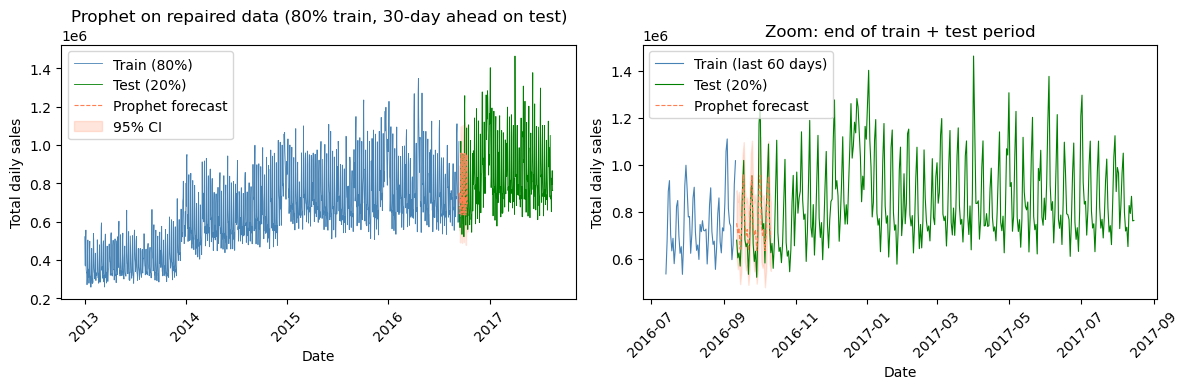

In [278]:
# Prophet on repaired data (prior to decomposition): 80% train, 20% test, then forecast and evaluate.
# Uses total_repaired from setup; no decomposition or seasonally adjusted series.
from prophet import Prophet

repaired_sorted = total_repaired.sort_index()
n_repaired = len(repaired_sorted)
train_size = int(0.8 * n_repaired)
train_repaired = repaired_sorted.iloc[:train_size]
test_repaired = repaired_sorted.iloc[train_size:]
# 30-day ahead forecast into the test period (or fewer if test is shorter)
horizon = min(30, len(test_repaired))

train_df = pd.DataFrame({"ds": train_repaired.index, "y": train_repaired.values})
prophet_repaired = Prophet(yearly_seasonality=True, weekly_seasonality=True, interval_width=0.95)
prophet_repaired.fit(train_df)

# Forecast over the test period
future_repaired = prophet_repaired.make_future_dataframe(periods=horizon)
forecast_repaired = prophet_repaired.predict(future_repaired)
fc_tail = forecast_repaired.tail(horizon)
fc_dates = pd.to_datetime(fc_tail["ds"])
prophet_fc = fc_tail["yhat"].values
prophet_fc_lower = fc_tail["yhat_lower"].values
prophet_fc_upper = fc_tail["yhat_upper"].values

# Align forecast with actual test dates and compute performance (by date so lengths match)
forecast_series = pd.Series(prophet_fc, index=pd.DatetimeIndex(fc_dates))
actual_test = test_repaired.reindex(forecast_series.index).dropna()
# Only use dates where we have both actual and forecast
common_ix = actual_test.index.intersection(forecast_series.index)
actual_vals = actual_test.reindex(common_ix).dropna().values
pred_vals = forecast_series.reindex(common_ix).dropna().values
if len(actual_vals) > 0 and len(actual_vals) == len(pred_vals):
    def mape(actual, pred):
        mask = actual != 0
        if mask.sum() == 0:
            return np.nan
        return 100 * np.mean(np.abs((actual - pred)[mask] / actual[mask]))

    results_repaired = pd.DataFrame([{
        "Method": "Prophet (repaired, 80% train, 30-day ahead)",
        "MAE": round(float(np.mean(np.abs(actual_vals - pred_vals))), 0),
        "RMSE": round(float(np.sqrt(np.mean((actual_vals - pred_vals) ** 2))), 0),
        "MAPE (%)": round(mape(actual_vals, pred_vals), 2),
    }])
    print("Prophet on repaired data (80% train, 30-day ahead on test):")
    display(results_repaired)
else:
    print("No overlapping actuals for test period; skipping MAE/RMSE/MAPE.")

# Plots: full series + zoom
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_repaired.index, train_repaired.values, color="steelblue", linewidth=0.6, label="Train (80%)")
axes[0].plot(test_repaired.index, test_repaired.values, color="green", linewidth=0.6, label="Test (20%)")
axes[0].plot(fc_dates, prophet_fc, color="coral", linewidth=0.8, linestyle="--", label="Prophet forecast")
axes[0].fill_between(fc_dates, prophet_fc_lower, prophet_fc_upper, color="coral", alpha=0.2, label="95% CI")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("Prophet on repaired data (80% train, 30-day ahead on test)")
axes[0].legend(loc="best")
axes[0].tick_params(axis="x", rotation=45)

# Zoom: last 60 days of train + test period
zoom_start = train_repaired.index[-60:] if len(train_repaired) >= 60 else train_repaired.index
axes[1].plot(zoom_start, train_repaired.reindex(zoom_start).dropna().values, color="steelblue", linewidth=0.8, label="Train (last 60 days)")
axes[1].plot(test_repaired.index, test_repaired.values, color="green", linewidth=0.8, label="Test (20%)")
axes[1].plot(fc_dates, prophet_fc, color="coral", linewidth=0.8, linestyle="--", label="Prophet forecast")
axes[1].fill_between(fc_dates, prophet_fc_lower, prophet_fc_upper, color="coral", alpha=0.2)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total daily sales")
axes[1].set_title("Zoom: end of train + test period")
axes[1].legend(loc="best")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## ETS (Holt-Winters) on repaired data (prior to decomposition)

Fit an **ETS (Holt-Winters)** model on the **total repaired daily sales** series (no OLS decomposition), using the same 80% train / 20% test split as the Prophet-on-repaired section. Produce a **30-day ahead forecast** into the test period and evaluate MAE, RMSE, and MAPE on those 30 days. This is comparable to the Prophet 30-day ahead forecast on repaired data above.

ETS on repaired data (80% train, 30-day ahead on test):


,Model,MAE,RMSE,MAPE (%)
0,"ETS (Holt-Winters, repaired, 80% train, 30-day...",77637.0,96119.0,10.54


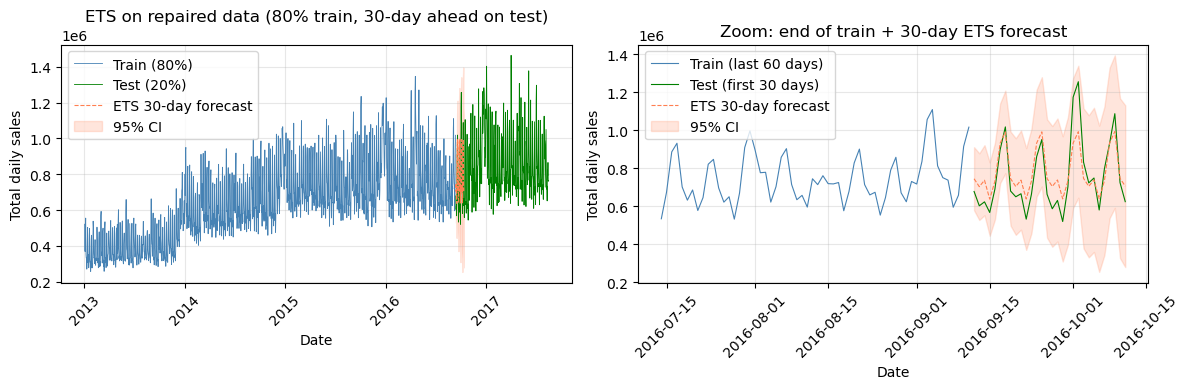

In [279]:
# ETS (Holt-Winters) on repaired data, prior to decomposition: 80% train, 30-day ahead forecast on test.
# Same split as Prophet-on-repaired (repaired_sorted 80/20).
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing

# Reuse same train/test split as Prophet on repaired (run that cell first, or define here)
repaired_sorted = total_repaired.sort_index()
n_repaired = len(repaired_sorted)
train_size = int(0.8 * n_repaired)
train_repaired = repaired_sorted.iloc[:train_size]
test_repaired = repaired_sorted.iloc[train_size:]
horizon_ets = min(30, len(test_repaired))

# Fit ETS on train only (additive trend, seasonal period 7)
ets_repaired = ExponentialSmoothing(train_repaired.values, trend=True, seasonal=7)
ets_fit_rep = ets_repaired.fit()
# 30-day ahead forecast with 95% confidence interval
ets_forecast_rep = ets_fit_rep.get_forecast(horizon_ets)
ets_fc_rep = ets_forecast_rep.predicted_mean
ets_conf_rep = ets_forecast_rep.conf_int(alpha=0.05)
ets_fc_rep_lower = np.asarray(ets_conf_rep[:, 0])
ets_fc_rep_upper = np.asarray(ets_conf_rep[:, 1])
future_dates_ets = test_repaired.index[:horizon_ets]

# Align with actual test dates and compute MAE, RMSE, MAPE
actual_ets = test_repaired.reindex(future_dates_ets).dropna()
if len(actual_ets) > 0 and len(actual_ets) == len(ets_fc_rep):
    def mape(a, p):
        mask = a != 0
        if mask.sum() == 0:
            return np.nan
        return 100 * np.mean(np.abs((a - p)[mask] / a[mask]))
    a_vals = actual_ets.values
    p_vals = np.asarray(ets_fc_rep).flatten()
    results_ets_rep = pd.DataFrame([{
        "Model": "ETS (Holt-Winters, repaired, 80% train, 30-day ahead)",
        "MAE": round(float(np.mean(np.abs(a_vals - p_vals))), 0),
        "RMSE": round(float(np.sqrt(np.mean((a_vals - p_vals) ** 2))), 0),
        "MAPE (%)": round(mape(a_vals, p_vals), 2),
    }])
    print("ETS on repaired data (80% train, 30-day ahead on test):")
    display(results_ets_rep)
else:
    print("Could not align actuals with ETS forecast; skipping metrics.")

# Plots: train, test, 30-day ETS forecast
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_repaired.index, train_repaired.values, color="steelblue", linewidth=0.6, label="Train (80%)")
axes[0].plot(test_repaired.index, test_repaired.values, color="green", linewidth=0.6, label="Test (20%)")
axes[0].plot(future_dates_ets, ets_fc_rep, color="coral", linewidth=0.8, linestyle="--", label="ETS 30-day forecast")
axes[0].fill_between(future_dates_ets, ets_fc_rep_lower, ets_fc_rep_upper, color="coral", alpha=0.2, label="95% CI")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("ETS on repaired data (80% train, 30-day ahead on test)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

# Zoom: last 60 days train + first 30 days of test/forecast
zoom_start = train_repaired.index[-60:] if len(train_repaired) >= 60 else train_repaired.index
axes[1].plot(zoom_start, train_repaired.reindex(zoom_start).dropna().values, color="steelblue", linewidth=0.8, label="Train (last 60 days)")
axes[1].plot(future_dates_ets, test_repaired.reindex(future_dates_ets).dropna().values, color="green", linewidth=0.8, label="Test (first 30 days)")
axes[1].plot(future_dates_ets, ets_fc_rep, color="coral", linewidth=0.8, linestyle="--", label="ETS 30-day forecast")
axes[1].fill_between(future_dates_ets, ets_fc_rep_lower, ets_fc_rep_upper, color="coral", alpha=0.2, label="95% CI")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total daily sales")
axes[1].set_title("Zoom: end of train + 30-day ETS forecast")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Exported (combined): data\ETS_Prophet_repaired_last60_train_30day_forecast.png


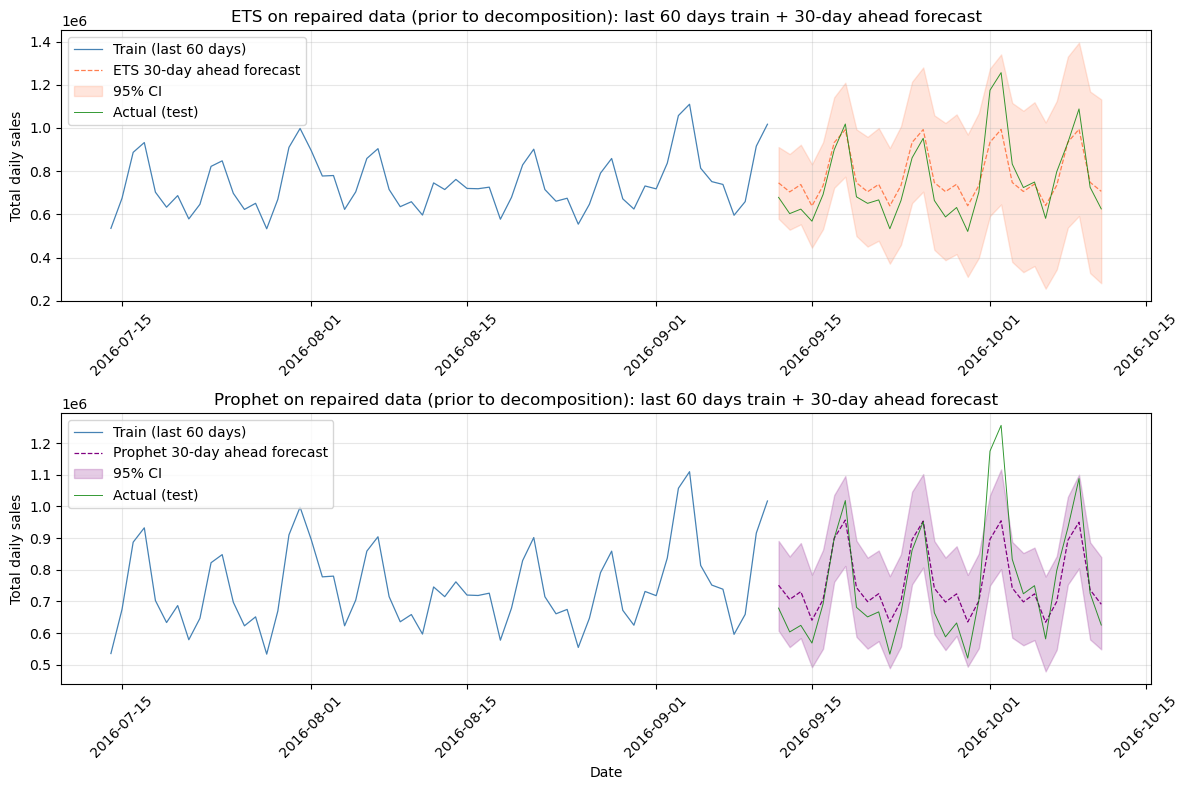

Exported (ETS): data\ETS_repaired_last60_train_30day_forecast.png
Exported (Prophet): data\Prophet_repaired_last60_train_30day_forecast.png


In [280]:
# Plot: last 60 days train + 30-day ahead forecast for ETS and Prophet (before decomposition). Export plots.
# Requires Prophet-on-repaired and ETS-on-repaired cells run (train_repaired, ets_fc_rep, future_dates_ets, prophet_fc, fc_dates).
import os
os.makedirs(DATA, exist_ok=True)

tail_60 = train_repaired.index[-60:] if len(train_repaired) >= 60 else train_repaired.index
train_last_60 = train_repaired.reindex(tail_60).dropna()
# 30-day forecast dates and actuals (same for both models)
fc_30_dates = future_dates_ets  # from ETS cell; same length as Prophet's 30-day
actual_30 = test_repaired.reindex(fc_30_dates).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
# ETS: last 60 days train + 30-day forecast
axes[0].plot(train_last_60.index, train_last_60.values, color="steelblue", linewidth=0.9, label="Train (last 60 days)")
axes[0].plot(future_dates_ets, ets_fc_rep, color="coral", linewidth=0.9, linestyle="--", label="ETS 30-day ahead forecast")
axes[0].fill_between(future_dates_ets, ets_fc_rep_lower, ets_fc_rep_upper, color="coral", alpha=0.2, label="95% CI")
axes[0].plot(actual_30.index, actual_30.values, color="green", linewidth=0.7, alpha=0.8, label="Actual (test)")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("ETS on repaired data (prior to decomposition): last 60 days train + 30-day ahead forecast")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)
# Prophet: last 60 days train + 30-day forecast
axes[1].plot(train_last_60.index, train_last_60.values, color="steelblue", linewidth=0.9, label="Train (last 60 days)")
axes[1].plot(fc_dates, prophet_fc, color="purple", linewidth=0.9, linestyle="--", label="Prophet 30-day ahead forecast")
axes[1].fill_between(fc_dates, prophet_fc_lower, prophet_fc_upper, color="purple", alpha=0.2, label="95% CI")
actual_30_prophet = test_repaired.reindex(fc_dates).dropna()
axes[1].plot(actual_30_prophet.index, actual_30_prophet.values, color="green", linewidth=0.7, alpha=0.8, label="Actual (test)")
axes[1].set_ylabel("Total daily sales")
axes[1].set_xlabel("Date")
axes[1].set_title("Prophet on repaired data (prior to decomposition): last 60 days train + 30-day ahead forecast")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
combined_path = os.path.join(DATA, "ETS_Prophet_repaired_last60_train_30day_forecast.png")
fig.savefig(combined_path, dpi=180, bbox_inches="tight")
print("Exported (combined):", combined_path)
plt.show()

# Export each plot separately
fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(train_last_60.index, train_last_60.values, color="steelblue", linewidth=0.9, label="Train (last 60 days)")
ax1.plot(future_dates_ets, ets_fc_rep, color="coral", linewidth=0.9, linestyle="--", label="ETS 30-day ahead forecast")
ax1.fill_between(future_dates_ets, ets_fc_rep_lower, ets_fc_rep_upper, color="coral", alpha=0.2, label="95% CI")
ax1.plot(actual_30.index, actual_30.values, color="green", linewidth=0.7, alpha=0.8, label="Actual (test)")
ax1.set_ylabel("Total daily sales")
ax1.set_xlabel("Date")
ax1.set_title("ETS on repaired data (prior to decomposition): last 60 days train + 30-day ahead forecast")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
ets_path = os.path.join(DATA, "ETS_repaired_last60_train_30day_forecast.png")
fig1.savefig(ets_path, dpi=180, bbox_inches="tight")
plt.close(fig1)
print("Exported (ETS):", ets_path)

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(train_last_60.index, train_last_60.values, color="steelblue", linewidth=0.9, label="Train (last 60 days)")
ax2.plot(fc_dates, prophet_fc, color="purple", linewidth=0.9, linestyle="--", label="Prophet 30-day ahead forecast")
ax2.fill_between(fc_dates, prophet_fc_lower, prophet_fc_upper, color="purple", alpha=0.2, label="95% CI")
ax2.plot(actual_30_prophet.index, actual_30_prophet.values, color="green", linewidth=0.7, alpha=0.8, label="Actual (test)")
ax2.set_ylabel("Total daily sales")
ax2.set_xlabel("Date")
ax2.set_title("Prophet on repaired data (prior to decomposition): last 60 days train + 30-day ahead forecast")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
prophet_path = os.path.join(DATA, "Prophet_repaired_last60_train_30day_forecast.png")
fig2.savefig(prophet_path, dpi=180, bbox_inches="tight")
plt.close(fig2)
print("Exported (Prophet):", prophet_path)

Exported (combined): data\ACF_PACF_ETS_Prophet_repaired_residuals.png


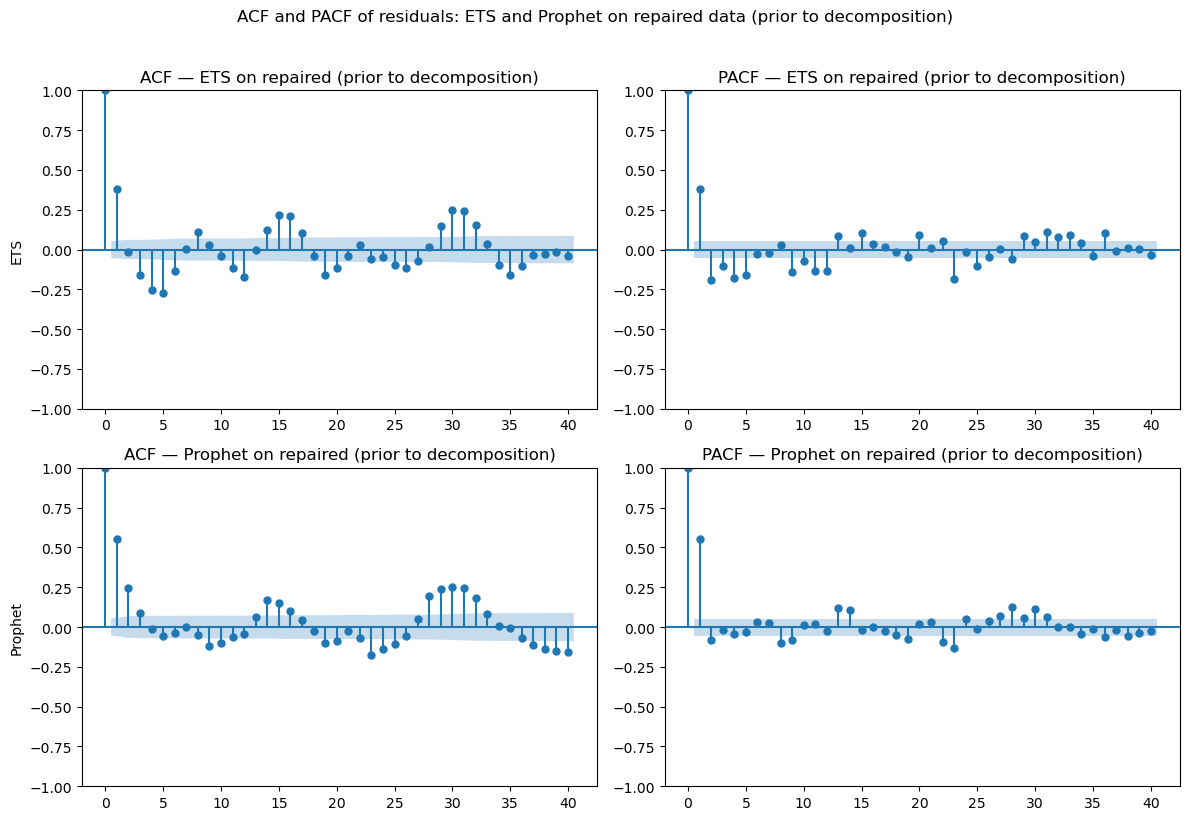

Exported (ETS): data\ACF_PACF_ETS_repaired_residuals.png
Exported (Prophet): data\ACF_PACF_Prophet_repaired_residuals.png


In [281]:
# ACF and PACF of in-sample residuals for ETS and Prophet (before decomposition). Export charts.
# Requires ETS-on-repaired and Prophet-on-repaired cells run (ets_fit_rep, prophet_repaired, train_repaired, train_df).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os
os.makedirs(DATA, exist_ok=True)

# ETS (on repaired) in-sample residuals
fitted_ets_rep = np.asarray(ets_fit_rep.fittedvalues).flatten()
n_ets = min(len(train_repaired), len(fitted_ets_rep))
resid_ets_rep = train_repaired.values[-n_ets:] - fitted_ets_rep[-n_ets:]

# Prophet (on repaired) in-sample residuals: train y - predicted yhat on train dates
pred_train_prophet = prophet_repaired.predict(train_df)
resid_prophet_rep = (train_repaired.values - pred_train_prophet["yhat"].values).flatten()

lags = 40
# Combined figure: 2 rows (ETS, Prophet) x 2 cols (ACF, PACF)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(resid_ets_rep, lags=lags, ax=axes[0, 0], title="ACF — ETS on repaired (prior to decomposition)")
plot_pacf(resid_ets_rep, lags=lags, ax=axes[0, 1], title="PACF — ETS on repaired (prior to decomposition)")
plot_acf(resid_prophet_rep, lags=lags, ax=axes[1, 0], title="ACF — Prophet on repaired (prior to decomposition)")
plot_pacf(resid_prophet_rep, lags=lags, ax=axes[1, 1], title="PACF — Prophet on repaired (prior to decomposition)")
axes[0, 0].set_ylabel("ETS")
axes[1, 0].set_ylabel("Prophet")
plt.suptitle("ACF and PACF of residuals: ETS and Prophet on repaired data (prior to decomposition)", y=1.02)
plt.tight_layout()
combined_path = os.path.join(DATA, "ACF_PACF_ETS_Prophet_repaired_residuals.png")
fig.savefig(combined_path, dpi=180, bbox_inches="tight")
print("Exported (combined):", combined_path)
plt.show()

# Export ETS ACF/PACF only
fig_ets, ax_ets = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid_ets_rep, lags=lags, ax=ax_ets[0], title="ACF — ETS on repaired (prior to decomposition)")
plot_pacf(resid_ets_rep, lags=lags, ax=ax_ets[1], title="PACF — ETS on repaired (prior to decomposition)")
plt.suptitle("ETS on repaired data (prior to decomposition): residual ACF and PACF", y=1.02)
plt.tight_layout()
ets_acf_path = os.path.join(DATA, "ACF_PACF_ETS_repaired_residuals.png")
fig_ets.savefig(ets_acf_path, dpi=180, bbox_inches="tight")
plt.close(fig_ets)
print("Exported (ETS):", ets_acf_path)

# Export Prophet ACF/PACF only
fig_prophet, ax_prophet = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid_prophet_rep, lags=lags, ax=ax_prophet[0], title="ACF — Prophet on repaired (prior to decomposition)")
plot_pacf(resid_prophet_rep, lags=lags, ax=ax_prophet[1], title="PACF — Prophet on repaired (prior to decomposition)")
plt.suptitle("Prophet on repaired data (prior to decomposition): residual ACF and PACF", y=1.02)
plt.tight_layout()
prophet_acf_path = os.path.join(DATA, "ACF_PACF_Prophet_repaired_residuals.png")
fig_prophet.savefig(prophet_acf_path, dpi=180, bbox_inches="tight")
plt.close(fig_prophet)
print("Exported (Prophet):", prophet_acf_path)

## Forecasting the residuals (ETS, ARIMA, Prophet)

Use the **OLS decomposition residuals** as the series to forecast. Fit **ETS**, **ARIMA**, and **Prophet** on the residual series (80% train from 2014 onward), forecast residuals for the first 30 days of the test period, then add back **trend** and **seasonal** (from the OLS decomposition) to obtain total sales forecasts. Report MAE, RMSE, MAPE and 95% confidence intervals.

### Cross-validation design

- **Train/test split:** Repaired data is split chronologically 80% train / 20% test (same as elsewhere in this notebook).
- **Pipeline (per fold):** For each two-week window in the test set:
  1. **OLS decomposition** (same specification as above): trend + day of week, day of month, week of year, New Year's Day. Fit on all data available up to the start of the window (expanding: train, then train + previous test days).
  2. **Residuals** from that OLS fit are the series to forecast.
  3. **ETS**, **ARIMA**, and **Prophet** are fit on the residual series (training portion only). Each model forecasts residuals for the next 14 days.
  4. **Full forecast** = OLS trend (for those 14 dates) + OLS seasonal (for those 14 dates) + residual forecast. Compare to actual total sales; record errors.
- **Increment:** Advance by 14 days through the test portion until the end of the test set.
- **Outputs:** MAE, RMSE, and MAPE (aggregated over all folds) for ETS, ARIMA, and Prophet; separate charts of predicted vs actual for each model.

c:\Users\cbailey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
15:27:43 - cmdstanpy - INFO - Chain [1] start processing
15:27:43 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\cbailey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
15:27:45 - cmdstanpy - INFO - Chain [1] start processing
15:27:45 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\cbailey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
15:27:46 - cmdstanpy - I

Model specifications (cross-validation: ETS, ARIMA, Prophet on OLS residuals):


,Model,Specification,Description
0,ETS (residuals + OLS),"Exponential smoothing (state space), additive ...",In each CV fold: fit ETS on the residual serie...
1,ARIMA (residuals + OLS),"ARIMA(p=2, d=1, q=2).","In each CV fold: fit ARIMA(2,1,2) on the resid..."
2,Prophet (residuals + OLS),"Prophet with yearly_seasonality=True, weekly_s...",In each CV fold: fit Prophet on the residual s...


Cross-validation metrics (two-week folds over test set; OLS decomposition, then ETS/ARIMA/Prophet on residuals):


,Model,MAE,RMSE,MAPE (%)
0,ETS (residuals + OLS),65032.0,89516.0,7.64
1,ARIMA (residuals + OLS),69302.0,90580.0,8.28
2,Prophet (residuals + OLS),64271.0,91426.0,7.17


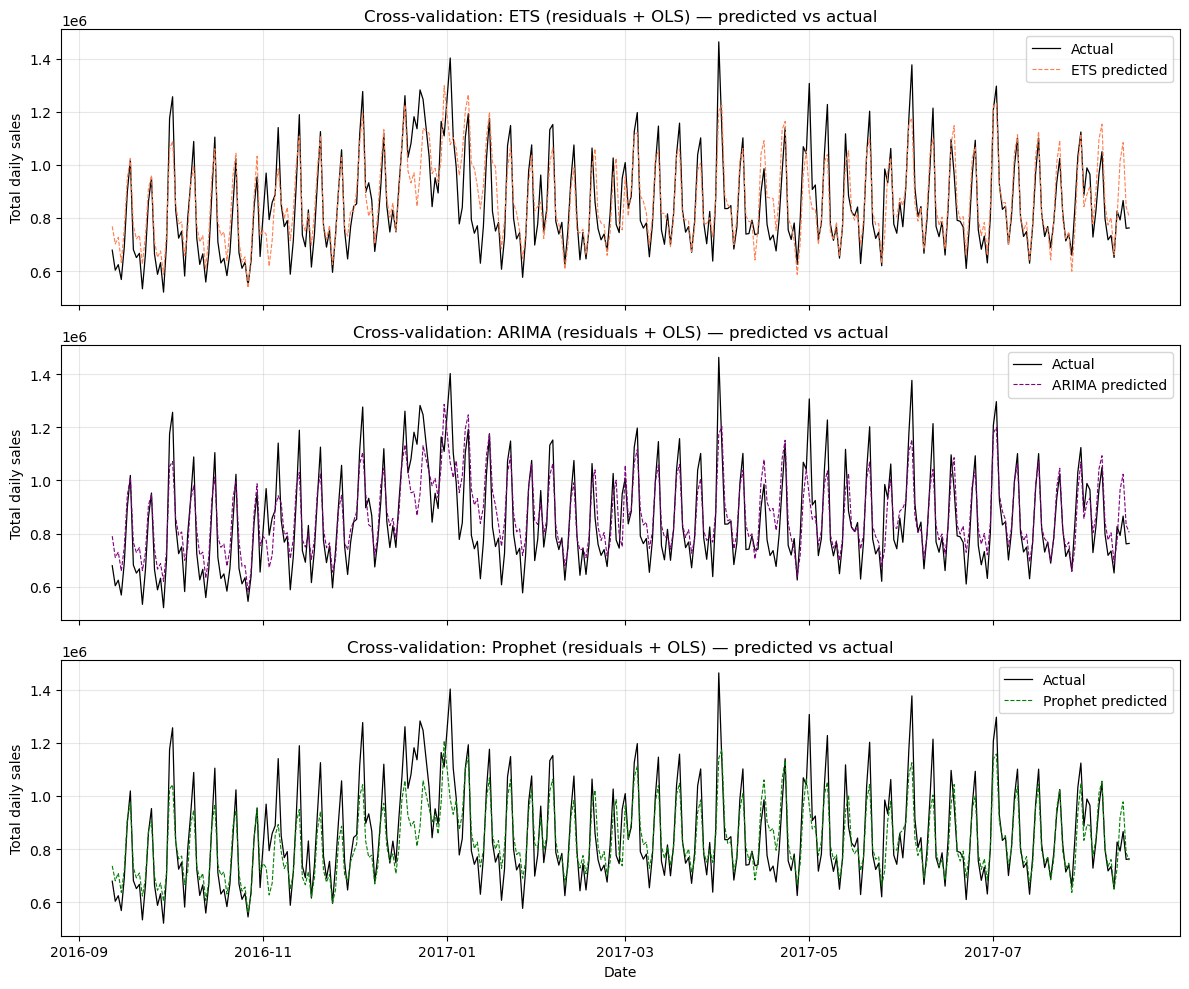

In [282]:
# Cross-validation: OLS decomposition then ETS, ARIMA, Prophet on residuals; two-week increments over test set.
# Requires: total_repaired, and run decomposition cell once so we reuse the same OLS design (dow, dom, woy, newyear).
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 80/20 split on repaired data (chronological) ---
repaired = total_repaired.sort_index()
n_total = len(repaired)
train_size = int(0.8 * n_total)
train_rep = repaired.iloc[:train_size]
test_rep = repaired.iloc[train_size:]
n_test = len(test_rep)
cv_step = 14  # two-week increments

def build_ols_design(series):
    """Build OLS design matrix (trend, newyear, dow, dom, woy dummies) for a series with DatetimeIndex."""
    y = series.values
    n = len(y)
    idx = series.index
    df = pd.DataFrame({"y": y, "trend": np.arange(n)}, index=idx)
    df["dow"] = df.index.dayofweek
    df["dom"] = df.index.day
    df["woy"] = df.index.isocalendar().week.astype(int)
    df["newyear"] = ((df.index.month == 1) & (df.index.day == 1)).astype(np.float64)
    X = add_constant(df[["trend"]])
    X["newyear"] = df["newyear"]
    X = X.join(pd.get_dummies(df["dow"], prefix="dow", drop_first=True))
    X = X.join(pd.get_dummies(df["dom"], prefix="dom", drop_first=True))
    X = X.join(pd.get_dummies(df["woy"], prefix="woy", drop_first=True))
    # Align columns to a common set (in case some dummies missing in a short series)
    return df, X

def build_X_future(future_dates, trend_start, X_template):
    """Build future design matrix for given dates; trend continues from trend_start."""
    horizon = len(future_dates)
    X_fut = pd.DataFrame(0.0, index=range(horizon), columns=X_template.columns)
    for i, date in enumerate(future_dates):
        X_fut.loc[i, "const"] = 1.0
        X_fut.loc[i, "trend"] = trend_start + i
        X_fut.loc[i, "newyear"] = 1.0 if (date.month == 1 and date.day == 1) else 0.0
        c = "dow_" + str(date.dayofweek)
        if c in X_fut.columns:
            X_fut.loc[i, c] = 1.0
        c = "dom_" + str(date.day)
        if c in X_fut.columns:
            X_fut.loc[i, c] = 1.0
        w = date.isocalendar().week
        c = "woy_" + str(w)
        if c in X_fut.columns:
            X_fut.loc[i, c] = 1.0
    return X_fut

def mape(actual, pred):
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((actual - pred)[mask] / actual[mask]))

# Collect predictions and actuals across all folds
all_dates = []
all_actual = []
all_pred_ets = []
all_pred_arima = []
all_pred_prophet = []

sk = 0
while sk + cv_step <= n_test:
    # --- Expanding data: train + test up to (but not including) current window ---
    end_prev = train_size + sk
    data_expand = repaired.iloc[:end_prev]
    future_dates_14 = test_rep.index[sk : sk + cv_step]

    # --- OLS decomposition on expanding data ---
    df_expand, X_expand = build_ols_design(data_expand)
    X_arr = np.asarray(X_expand, dtype=np.float64)
    y_arr = np.asarray(df_expand["y"].values, dtype=np.float64)
    model_cv = OLS(y_arr, X_arr).fit()
    fitted_cv = model_cv.predict(X_arr)
    trend_cv = model_cv.params[0] + model_cv.params[1] * df_expand["trend"].values
    seasonal_cv = fitted_cv - trend_cv
    resid_cv = (df_expand["y"].values - fitted_cv)

    # --- Trend and seasonal for the next 14 days (same OLS coefficients) ---
    X_fut = build_X_future(future_dates_14, len(data_expand), X_expand)
    seasonal_cols = [c for c in X_expand.columns if c not in ("const", "trend")]
    beta_seasonal = np.asarray(model_cv.params[2:])
    trend_future = model_cv.params[0] + model_cv.params[1] * X_fut["trend"].values
    seasonal_future = X_fut[seasonal_cols].reindex(columns=seasonal_cols).fillna(0).values @ beta_seasonal

    # --- ETS on residuals: fit, forecast 14 steps ---
    ets_cv = ExponentialSmoothing(resid_cv, trend=True, seasonal=7)
    ets_fit_cv = ets_cv.fit()
    ets_fc_cv = ets_fit_cv.forecast(cv_step)
    full_ets = trend_future + seasonal_future + np.asarray(ets_fc_cv)

    # --- ARIMA on residuals: fit, forecast 14 steps ---
    arima_cv = ARIMA(resid_cv, order=(2, 1, 2))
    arima_fit_cv = arima_cv.fit()
    arima_fc_cv = arima_fit_cv.forecast(cv_step)
    full_arima = trend_future + seasonal_future + np.asarray(arima_fc_cv)

    # --- Prophet on residuals: fit on (ds, y), forecast 14 days ---
    resid_series = pd.Series(resid_cv, index=data_expand.index)
    df_prophet = pd.DataFrame({"ds": resid_series.index, "y": resid_series.values})
    prophet_cv = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    prophet_cv.fit(df_prophet)
    future_14 = prophet_cv.make_future_dataframe(periods=cv_step)
    forecast_14 = prophet_cv.predict(future_14)
    resid_prophet_fc = forecast_14["yhat"].tail(cv_step).values
    full_prophet = trend_future + seasonal_future + resid_prophet_fc

    actual_14 = test_rep.iloc[sk : sk + cv_step].values
    all_dates.extend(future_dates_14)
    all_actual.extend(actual_14)
    all_pred_ets.extend(full_ets)
    all_pred_arima.extend(full_arima)
    all_pred_prophet.extend(full_prophet)
    sk += cv_step

all_actual = np.asarray(all_actual)
all_pred_ets = np.asarray(all_pred_ets)
all_pred_arima = np.asarray(all_pred_arima)
all_pred_prophet = np.asarray(all_pred_prophet)

# --- Model specifications (with description), shown before performance metrics ---
specs_cv = pd.DataFrame([
    {
        "Model": "ETS (residuals + OLS)",
        "Specification": "Exponential smoothing (state space), additive trend, seasonal period = 7 (weekly).",
        "Description": "In each CV fold: fit ETS on the residual series (OLS decomposition residuals); forecast 14 days ahead; add back OLS trend + seasonal to get total sales forecast.",
    },
    {
        "Model": "ARIMA (residuals + OLS)",
        "Specification": "ARIMA(p=2, d=1, q=2).",
        "Description": "In each CV fold: fit ARIMA(2,1,2) on the residual series; forecast 14 steps; add back OLS trend + seasonal to get total sales forecast.",
    },
    {
        "Model": "Prophet (residuals + OLS)",
        "Specification": "Prophet with yearly_seasonality=True, weekly_seasonality=True (additive seasonality).",
        "Description": "In each CV fold: fit Prophet on the residual series (ds, y); forecast 14 days; add back OLS trend + seasonal to get total sales forecast.",
    },
])
print("Model specifications (cross-validation: ETS, ARIMA, Prophet on OLS residuals):")
display(specs_cv)

# --- Metrics (MAE, RMSE, MAPE) for each model ---
def metrics_row(name, actual, pred):
    return {
        "Model": name,
        "MAE": round(float(np.mean(np.abs(actual - pred))), 0),
        "RMSE": round(float(np.sqrt(np.mean((actual - pred) ** 2))), 0),
        "MAPE (%)": round(mape(actual, pred), 2),
    }

results_cv = pd.DataFrame([
    metrics_row("ETS (residuals + OLS)", all_actual, all_pred_ets),
    metrics_row("ARIMA (residuals + OLS)", all_actual, all_pred_arima),
    metrics_row("Prophet (residuals + OLS)", all_actual, all_pred_prophet),
])
print("Cross-validation metrics (two-week folds over test set; OLS decomposition, then ETS/ARIMA/Prophet on residuals):")
display(results_cv)

# --- Three separate charts: predicted vs actual for each model ---
dates_cv = pd.DatetimeIndex(all_dates)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(dates_cv, all_actual, color="black", linewidth=0.9, label="Actual")
axes[0].plot(dates_cv, all_pred_ets, color="coral", linewidth=0.8, linestyle="--", label="ETS predicted")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("Cross-validation: ETS (residuals + OLS) — predicted vs actual")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates_cv, all_actual, color="black", linewidth=0.9, label="Actual")
axes[1].plot(dates_cv, all_pred_arima, color="purple", linewidth=0.8, linestyle="--", label="ARIMA predicted")
axes[1].set_ylabel("Total daily sales")
axes[1].set_title("Cross-validation: ARIMA (residuals + OLS) — predicted vs actual")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

axes[2].plot(dates_cv, all_actual, color="black", linewidth=0.9, label="Actual")
axes[2].plot(dates_cv, all_pred_prophet, color="green", linewidth=0.8, linestyle="--", label="Prophet predicted")
axes[2].set_ylabel("Total daily sales")
axes[2].set_xlabel("Date")
axes[2].set_title("Cross-validation: Prophet (residuals + OLS) — predicted vs actual")
axes[2].legend(loc="best")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Exported: data\ACF_PACF_CV_ETS_ARIMA_Prophet_residuals.png


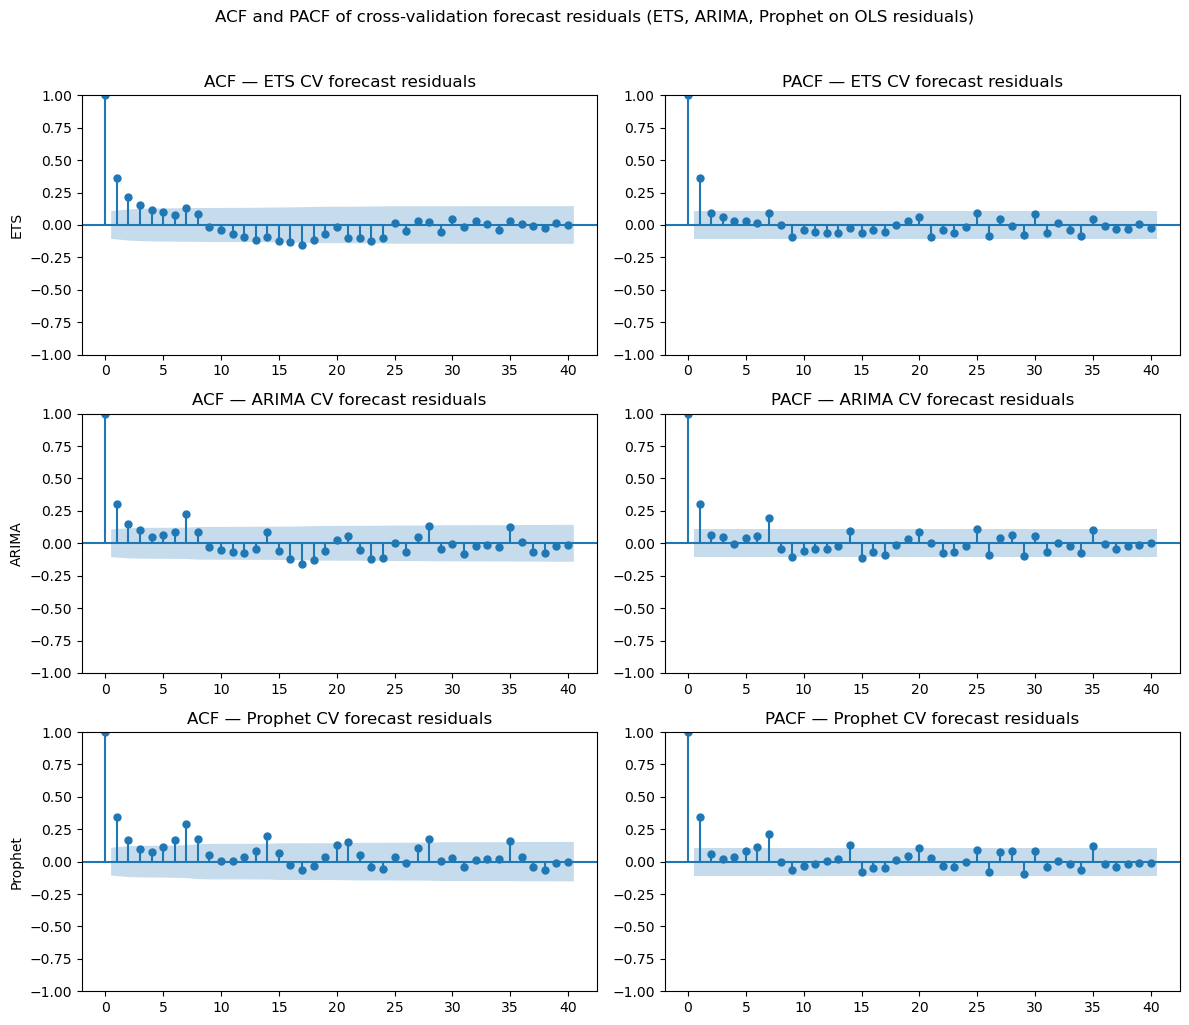

In [283]:
# ACF and PACF of cross-validation forecast residuals (actual - predicted) for ETS, ARIMA, Prophet.
# Requires the previous CV cell (all_actual, all_pred_ets, all_pred_arima, all_pred_prophet).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

resid_ets_cv = all_actual - all_pred_ets
resid_arima_cv = all_actual - all_pred_arima
resid_prophet_cv = all_actual - all_pred_prophet

lags = 40
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
plot_acf(resid_ets_cv, lags=lags, ax=axes[0, 0], title="ACF — ETS CV forecast residuals")
plot_pacf(resid_ets_cv, lags=lags, ax=axes[0, 1], title="PACF — ETS CV forecast residuals")
plot_acf(resid_arima_cv, lags=lags, ax=axes[1, 0], title="ACF — ARIMA CV forecast residuals")
plot_pacf(resid_arima_cv, lags=lags, ax=axes[1, 1], title="PACF — ARIMA CV forecast residuals")
plot_acf(resid_prophet_cv, lags=lags, ax=axes[2, 0], title="ACF — Prophet CV forecast residuals")
plot_pacf(resid_prophet_cv, lags=lags, ax=axes[2, 1], title="PACF — Prophet CV forecast residuals")
axes[0, 0].set_ylabel("ETS")
axes[1, 0].set_ylabel("ARIMA")
axes[2, 0].set_ylabel("Prophet")
plt.suptitle("ACF and PACF of cross-validation forecast residuals (ETS, ARIMA, Prophet on OLS residuals)", y=1.02)
plt.tight_layout()
os.makedirs(DATA, exist_ok=True)
acf_cv_path = os.path.join(DATA, "ACF_PACF_CV_ETS_ARIMA_Prophet_residuals.png")
fig.savefig(acf_cv_path, dpi=180, bbox_inches="tight")
print("Exported:", acf_cv_path)
plt.show()

Exported: data\ACF_PACF_CV_ETS_residuals.png


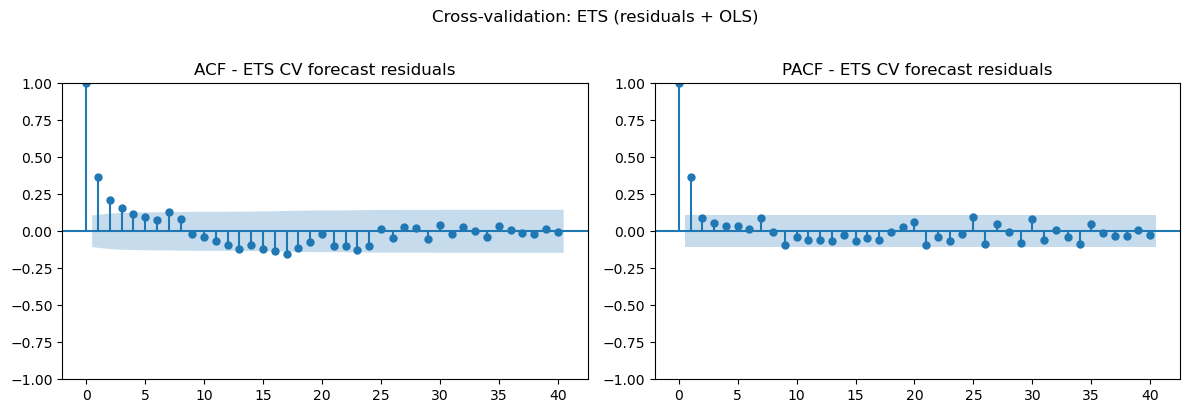

Exported: data\ACF_PACF_CV_ARIMA_residuals.png


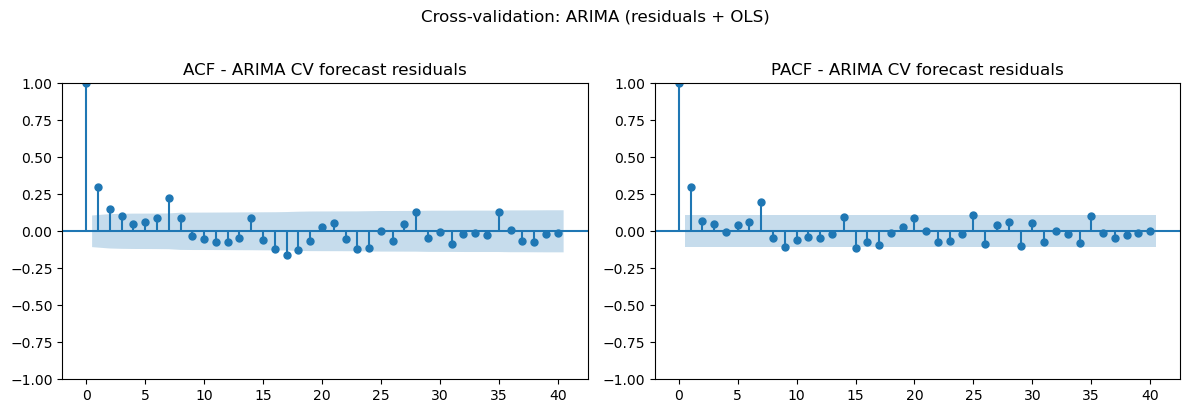

Exported: data\ACF_PACF_CV_Prophet_residuals.png


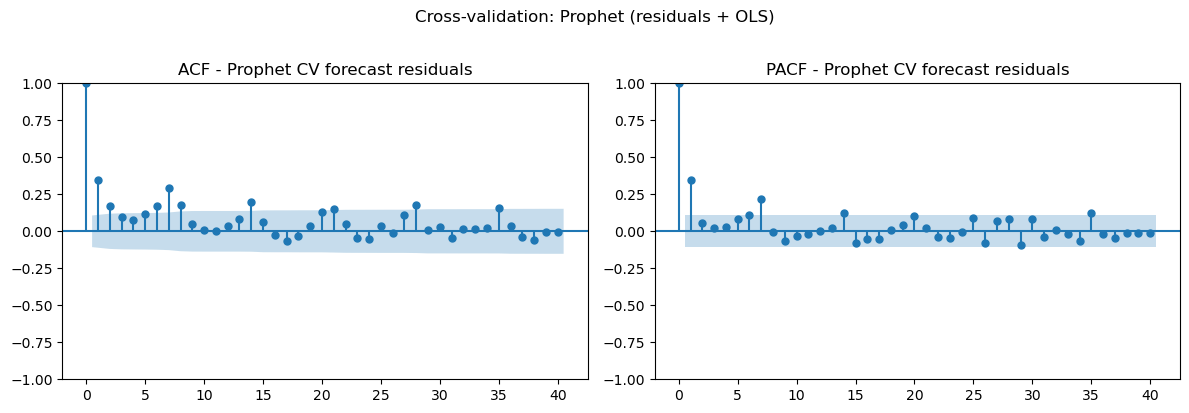

In [284]:
# Separate ACF/PACF figures per CV model (uses resid_ets_cv, resid_arima_cv, resid_prophet_cv from cell above).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
lags = 40
for name, resid in [("ETS", resid_ets_cv), ("ARIMA", resid_arima_cv), ("Prophet", resid_prophet_cv)]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(resid, lags=lags, ax=axes[0], title=f"ACF - {name} CV forecast residuals")
    plot_pacf(resid, lags=lags, ax=axes[1], title=f"PACF - {name} CV forecast residuals")
    plt.suptitle(f"Cross-validation: {name} (residuals + OLS)", y=1.02)
    plt.tight_layout()
    p = os.path.join(DATA, f"ACF_PACF_CV_{name}_residuals.png")
    fig.savefig(p, dpi=180, bbox_inches="tight")
    print("Exported:", p)
    plt.show()

### Regressions of CV forecast residuals on onpromotion and holidays

Regress each cross-validation model's forecast residuals (y) on:
1. **Daily sum of onpromotion** (from `train.csv`): one OLS per model (ETS, ARIMA, Prophet).
2. **Holiday indicator** (from `holidays_events.csv`): 1 if the date is a holiday, 0 otherwise; one OLS per model.

Requires the CV cell and the ACF/PACF CV cell to have been run (`dates_cv`, `resid_ets_cv`, `resid_arima_cv`, `resid_prophet_cv`).

In [285]:
# Regressions of CV forecast residuals (y) on daily onpromotion and on holiday indicator.
# Requires: CV cell and ACF/PACF CV cell run (dates_cv, resid_ets_cv, resid_arima_cv, resid_prophet_cv).
from statsmodels.api import OLS, add_constant

# Daily sum of onpromotion (same as promotion analysis)
train = pd.read_csv(f"{DATA}/train.csv", parse_dates=["date"])
daily_onpromo = train.groupby("date")["onpromotion"].sum()

# Holidays: load holidays_events.csv, keep Holiday (and optionally Transfer) dates, unique by date
holidays_df = pd.read_csv(f"{DATA}/holidays_events.csv", parse_dates=["date"])
holiday_dates = set(pd.to_datetime(holidays_df.loc[holidays_df["type"].isin(["Holiday", "Transfer"]), "date"]).dt.normalize().dt.date)

# Align to CV dates (dates_cv from the CV cell)
onpromo_cv = daily_onpromo.reindex(dates_cv).fillna(0).values
holiday_cv = np.array([1 if d.date() in holiday_dates else 0 for d in dates_cv])

# DataFrame for regressions: one row per CV date
df_cv = pd.DataFrame({
    "resid_ets": resid_ets_cv,
    "resid_arima": resid_arima_cv,
    "resid_prophet": resid_prophet_cv,
    "onpromo": onpromo_cv,
    "holiday": holiday_cv,
}, index=dates_cv)

# --- Regressions: residuals ~ onpromotion (separate for each model) ---
print("=" * 60)
print("OLS: CV forecast residuals (y) ~ daily sum of onpromotion (x)")
print("=" * 60)
for name, y_col in [("ETS", "resid_ets"), ("ARIMA", "resid_arima"), ("Prophet", "resid_prophet")]:
    print(f"\n--- {name} CV residuals ~ onpromo ---")
    X_op = add_constant(df_cv[["onpromo"]])
    mod_op = OLS(df_cv[y_col], X_op).fit()
    display(mod_op.summary().tables[0])
    display(mod_op.summary().tables[1])

# --- Regressions: residuals ~ holiday (separate for each model) ---
print("\n" + "=" * 60)
print("OLS: CV forecast residuals (y) ~ holiday indicator (1 = holiday, 0 = non-holiday)")
print("=" * 60)
for name, y_col in [("ETS", "resid_ets"), ("ARIMA", "resid_arima"), ("Prophet", "resid_prophet")]:
    print(f"\n--- {name} CV residuals ~ holiday ---")
    X_hol = add_constant(df_cv[["holiday"]])
    mod_hol = OLS(df_cv[y_col], X_hol).fit()
    display(mod_hol.summary().tables[0])
    display(mod_hol.summary().tables[1])

OLS: CV forecast residuals (y) ~ daily sum of onpromotion (x)

--- ETS CV residuals ~ onpromo ---


Dep. Variable:,resid_ets,R-squared:,0.023
Model:,OLS,Adj. R-squared:,0.020
Method:,Least Squares,F-statistic:,8.008
Date:,"Wed, 25 Feb 2026",Prob (F-statistic):,0.00494
Time:,15:28:25,Log-Likelihood:,-4299.3
No. Observations:,336,AIC:,8603.
Df Residuals:,334,BIC:,8610.
Df Model:,1,,
Covariance Type:,nonrobust,,


,coef,std err,t,P>|t|,[0.025,0.975]
const,-5.914e+04,1.64e+04,-3.609,0.000,-9.14e+04,-2.69e+04
onpromo,3.4771,1.229,2.830,0.005,1.060,5.894



--- ARIMA CV residuals ~ onpromo ---


Dep. Variable:,resid_arima,R-squared:,0.034
Model:,OLS,Adj. R-squared:,0.031
Method:,Least Squares,F-statistic:,11.76
Date:,"Wed, 25 Feb 2026",Prob (F-statistic):,0.000682
Time:,15:28:25,Log-Likelihood:,-4300.1
No. Observations:,336,AIC:,8604.
Df Residuals:,334,BIC:,8612.
Df Model:,1,,
Covariance Type:,nonrobust,,


...

Dep. Variable:,resid_arima,R-squared:,0.066
Model:,OLS,Adj. R-squared:,0.063
Method:,Least Squares,F-statistic:,23.47
Date:,"Wed, 25 Feb 2026",Prob (F-statistic):,1.94e-06
Time:,15:28:25,Log-Likelihood:,-4294.5
No. Observations:,336,AIC:,8593.
Df Residuals:,334,BIC:,8601.
Df Model:,1,,
Covariance Type:,nonrobust,,


,coef,std err,t,P>|t|,[0.025,0.975]
const,-2.453e+04,4964.860,-4.940,0.000,-3.43e+04,-1.48e+04
holiday,7.562e+04,1.56e+04,4.845,0.000,4.49e+04,1.06e+05



--- Prophet CV residuals ~ holiday ---


Dep. Variable:,resid_prophet,R-squared:,0.070
Model:,OLS,Adj. R-squared:,0.067
Method:,Least Squares,F-statistic:,25.03
Date:,"Wed, 25 Feb 2026",Prob (F-statistic):,9.15e-07
Time:,15:28:25,Log-Likelihood:,-4296.3
No. Observations:,336,AIC:,8597.
Df Residuals:,334,BIC:,8604.
Df Model:,1,,
Covariance Type:,nonrobust,,


,coef,std err,t,P>|t|,[0.025,0.975]
const,9926.6342,4991.278,1.989,0.048,108.330,1.97e+04
holiday,7.85e+04,1.57e+04,5.003,0.000,4.76e+04,1.09e+05


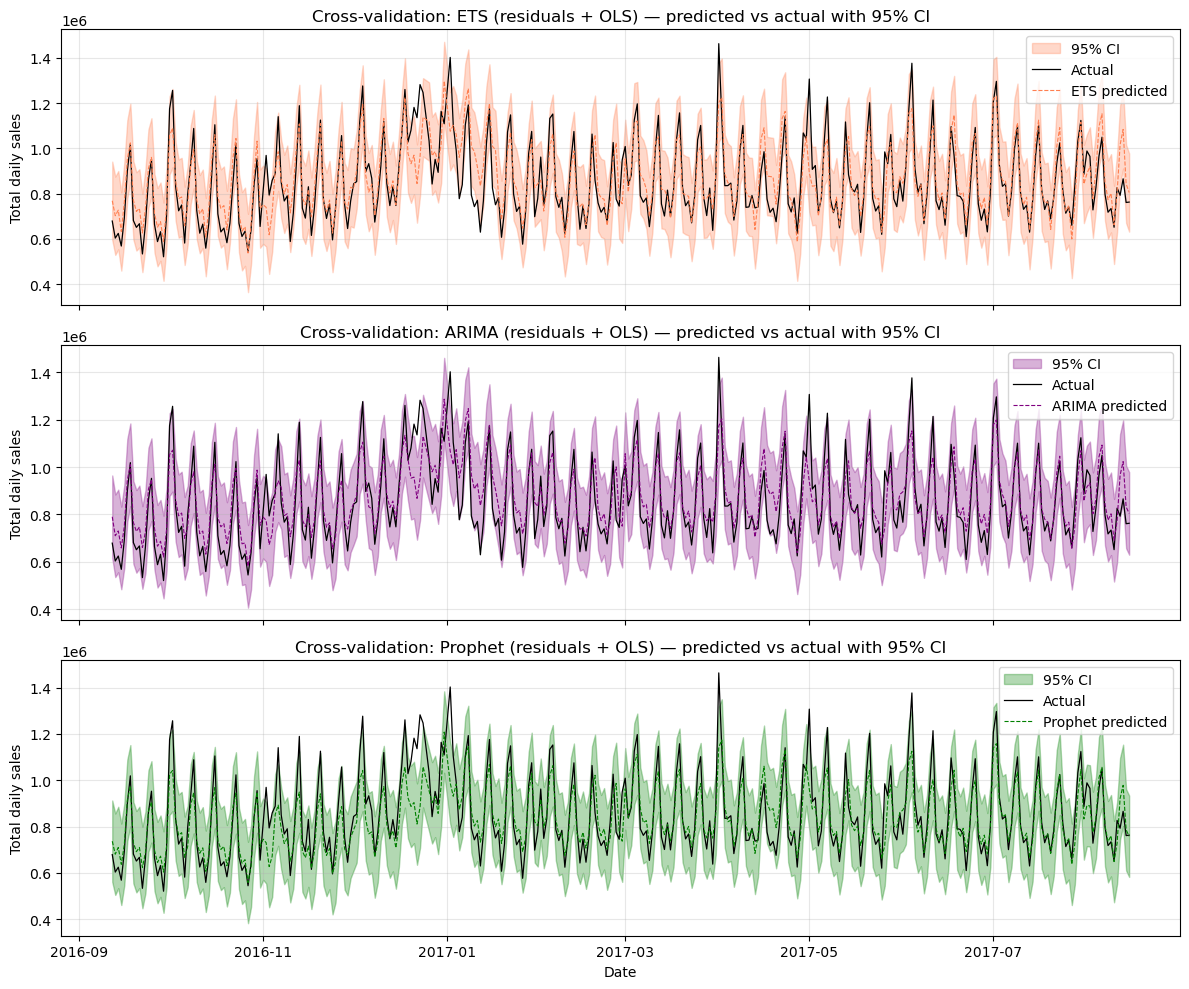

In [286]:
# Replicate the three cross-validation plots with 95% confidence intervals.
# CIs are based on residual standard error per model: pred ± 1.96 * std(residuals).
# Requires the previous CV cell to have been run (dates_cv, all_actual, all_pred_ets, all_pred_arima, all_pred_prophet).

res_ets = all_actual - all_pred_ets
res_arima = all_actual - all_pred_arima
res_prophet = all_actual - all_pred_prophet

se_ets = np.std(res_ets)
se_arima = np.std(res_arima)
se_prophet = np.std(res_prophet)

half_95 = 1.96  # 95% CI half-width in standard errors
lo_ets = all_pred_ets - half_95 * se_ets
hi_ets = all_pred_ets + half_95 * se_ets
lo_arima = all_pred_arima - half_95 * se_arima
hi_arima = all_pred_arima + half_95 * se_arima
lo_prophet = all_pred_prophet - half_95 * se_prophet
hi_prophet = all_pred_prophet + half_95 * se_prophet

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].fill_between(dates_cv, lo_ets, hi_ets, color="coral", alpha=0.3, label="95% CI")
axes[0].plot(dates_cv, all_actual, color="black", linewidth=0.9, label="Actual")
axes[0].plot(dates_cv, all_pred_ets, color="coral", linewidth=0.8, linestyle="--", label="ETS predicted")
axes[0].set_ylabel("Total daily sales")
axes[0].set_title("Cross-validation: ETS (residuals + OLS) — predicted vs actual with 95% CI")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(dates_cv, lo_arima, hi_arima, color="purple", alpha=0.3, label="95% CI")
axes[1].plot(dates_cv, all_actual, color="black", linewidth=0.9, label="Actual")
axes[1].plot(dates_cv, all_pred_arima, color="purple", linewidth=0.8, linestyle="--", label="ARIMA predicted")
axes[1].set_ylabel("Total daily sales")
axes[1].set_title("Cross-validation: ARIMA (residuals + OLS) — predicted vs actual with 95% CI")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

axes[2].fill_between(dates_cv, lo_prophet, hi_prophet, color="green", alpha=0.3, label="95% CI")
axes[2].plot(dates_cv, all_actual, color="black", linewidth=0.9, label="Actual")
axes[2].plot(dates_cv, all_pred_prophet, color="green", linewidth=0.8, linestyle="--", label="Prophet predicted")
axes[2].set_ylabel("Total daily sales")
axes[2].set_xlabel("Date")
axes[2].set_title("Cross-validation: Prophet (residuals + OLS) — predicted vs actual with 95% CI")
axes[2].legend(loc="best")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [287]:
# Export cross-validation plot data (actual and predicted for ETS, ARIMA, Prophet) to Excel.
df_export = pd.DataFrame({
    "Date": dates_cv,
    "Actual": all_actual,
    "ETS_predicted": all_pred_ets,
    "ARIMA_predicted": all_pred_arima,
    "Prophet_predicted": all_pred_prophet,
})
out_path = "data/Cross_Validation_Forecasts.xlsx"
df_export.to_excel(out_path, index=False)
print(f"Exported {len(df_export)} rows to {out_path}")

Exported 336 rows to data/Cross_Validation_Forecasts.xlsx


## Export plots to PowerPoint

Run the cell below to export all plots from this notebook (including the box plots above) to **3_and_4_Decomposition_and_Modeling_Plots.pptx**. Save the notebook (Ctrl+S) first so the latest figure outputs are included.

In [288]:
# Export this notebook's plots to PowerPoint (run after saving the notebook)
import subprocess
import sys
import os
from datetime import datetime

export_dir = os.getcwd()
pptx_name = "3_and_4_Decomposition_and_Modeling_Plots.pptx"
pptx_path = os.path.join(export_dir, pptx_name)

print("PowerPoint will be exported to:", os.path.abspath(export_dir))
print("File name:", pptx_name)
print("Full path:", os.path.abspath(pptx_path))

# Check timestamp of .pptx before running (for troubleshooting)
if os.path.isfile(pptx_path):
    mtime_before = os.path.getmtime(pptx_path)
    print("Timestamp of .pptx BEFORE export:", datetime.fromtimestamp(mtime_before))
else:
    mtime_before = None
    print("No existing .pptx file before export.")

script_path = os.path.join(export_dir, "export_notebook_plots_to_pptx.py")
if os.path.isfile(script_path):
    result = subprocess.run(
        [sys.executable, script_path],
        cwd=export_dir,
        capture_output=True,
        text=True,
        timeout=60
    )
    print("--- Script stdout ---")
    print(result.stdout if result.stdout else "(none)")
    if result.stderr:
        print("--- Script stderr ---")
        print(result.stderr)
    print("Script return code:", result.returncode)
    if result.returncode != 0:
        print("WARNING: Export script did not complete successfully.")

    # Check timestamp after
    if os.path.isfile(pptx_path):
        mtime_after = os.path.getmtime(pptx_path)
        print("Timestamp of .pptx AFTER export:", datetime.fromtimestamp(mtime_after))
        if mtime_before is not None and mtime_after <= mtime_before:
            print("WARNING: .pptx file was NOT updated (timestamp unchanged or older). Save the notebook first so plot outputs are written to disk.")
        else:
            print("OK: .pptx file was updated.")
    else:
        print("WARNING: .pptx file was not created. Check script output above.")
else:
    print("Export script not found at", script_path, "- run from the folder that contains export_notebook_plots_to_pptx.py")

PowerPoint will be exported to: c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term
File name: 3_and_4_Decomposition_and_Modeling_Plots.pptx
Full path: c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term\3_and_4_Decomposition_and_Modeling_Plots.pptx
Timestamp of .pptx BEFORE export: 2026-02-25 15:11:39.409401
--- Script stdout ---
Exporting notebook plots to PowerPoint (one .pptx per notebook)...

1_Data Structure:
  Saved 3 plot(s) to c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term\1_Data_Structure_Plots.pptx

2_Visualization:
  Saved 8 plot(s) to c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term\2_Visualization_Plots.pptx

2a_Data_Repair:
  Saved 7 plot(s) to c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term\2a_Data_Repair_Plots.pptx

3_and_4_Decomposition_and_Modeling:
  Saved 21 plot(s) to c:\Users\cbailey\Documents\Northeastern_ECON\ECON_5140\Mid_Term\3_and_4_Decomposition_and_Modeling_Plots.pptx

5_Evaluation_and